<a href="https://colab.research.google.com/github/Apostolis06/Big-Data-AUEB-Course/blob/main/FinTechCourse_W1_Apostolis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 · From Raw Financial Data to First Insights
### FinTech & AI Engineering — MSc Banking & Finance

---

## 🧭 Where this course is going (read this first)

Over the next 11 weeks you are going to build, step by step, your own **AI-native financial analytics product**. Its engine will be a small pipeline of AI agents (think about this as being a small Startup) — a *Data Agent*, an *Analyst Agent*, a *Risk Agent* — and your role will be that of the **orchestrator**: the person who specifies what the agents do, verifies their output, and takes responsibility for the result. This is exactly the role emerging across banks, asset managers, and FinTechs today.

There is one iron rule in this course:

> **Human first, agent second.** Before you are allowed to delegate a task to an AI agent, you must be able to do it yourself and *verify* it with theory. An agent you cannot audit is a black box, and black boxes have no place in finance.

**This week you do everything by hand.** You will download real market data, load it into Python, and extract its first secrets: returns, volatility, fat tails, drawdowns, correlations. In later weeks, an agent will do this for you in seconds — and you will be the one who can tell whether it did it *correctly*.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Acquire real financial time-series data (equities, FX, crypto) and load it from Excel/CSV files into Python.
2. Explain what every library in our toolkit does and why we need it.
3. Transform prices into **returns** and explain why finance works with returns, not prices.
4. Produce and *interpret* six fundamental charts every analyst uses on day one with a new dataset.
5. Compute and interpret a professional summary-statistics table (annualized return, volatility, Sharpe ratio, skewness, kurtosis, maximum drawdown, VaR).
6. State the **stylized facts** of financial returns — the empirical regularities that every model in this course must respect.

## 🗺️ How to use this notebook

Run cells top to bottom (`Shift+Enter`). Markdown cells carry the theory; code cells carry the practice, with every step commented. Two sections at the end (SQL, GitHub) are **optional** — recommended, but not graded.


---
# 1 · The toolkit — what each library does and why we need it

Python by itself knows almost nothing about data. Its power comes from **libraries**: collections of pre-built, battle-tested code that we import. Think of Python as the workshop and libraries as the machine tools. Ours for this week:

| Library | What it is | Why we need it here |
|---|---|---|
| **`pandas`** | The de-facto standard for tabular data in Python. Its core object, the `DataFrame`, is essentially a programmable Excel sheet: rows, columns, labels. | Loading Excel/CSV files, aligning dates, computing returns, rolling statistics. ~90% of a data analyst's day lives here. |
| **`numpy`** | The numerical engine underneath pandas. Provides fast arrays and mathematical functions (`log`, `sqrt`, random numbers). | Log returns, annualization ($\sqrt{252}$), and our synthetic-data fallback. |
| **`matplotlib`** | The foundational plotting library. Nearly every Python chart you have ever seen was drawn by it, directly or indirectly. | All six of our exploratory charts. |
| **`openpyxl`** | A reader/writer for `.xlsx` files. pandas calls it behind the scenes whenever you use `read_excel`. | Lets us load the Excel files you download. |
| **`pathlib`** | Part of Python's standard library — object-oriented file paths. | Checking which data files exist, in a way that works identically on Windows, macOS, and Linux. |
| **`sqlite3`** | A complete SQL database engine that ships *inside* Python — no installation, no server. | The optional SQL appendix. |

**Installation** (one-time, in a terminal or a notebook cell prefixed with `!`):

```bash
pip install pandas numpy matplotlib openpyxl
```

The cell below imports everything and prints the versions — your first sanity check. If it runs without errors, your environment is ready.


In [2]:
# ============================================================
# Cell 1 — Imports and environment check
# ============================================================
# The `import X as y` pattern gives a library a short alias.
# These aliases (pd, np, plt) are universal conventions — every
# tutorial, colleague, and AI assistant will use the same ones.

import sys                      # access to the Python interpreter itself (version info)
from pathlib import Path        # object-oriented, cross-platform file paths

import numpy as np              # numerical arrays and math functions
import pandas as pd             # DataFrames: labeled, tabular data
import matplotlib.pyplot as plt # plotting

# Display settings: make pandas output readable in class
pd.set_option("display.max_columns", 12)   # show up to 12 columns
pd.set_option("display.width", 120)        # wider console output
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")  # 4 decimals, thousands sep

# Reproducibility: any randomness in this notebook uses this seed,
# so everyone in class sees exactly the same numbers.
RNG = np.random.default_rng(seed=42)

print("Python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("✅ Environment ready.")


Python  : 3.13.15
pandas  : 2.2.3
numpy   : 2.1.3
✅ Environment ready.


---
# 2 · Getting the data — three assets, three asset classes

We deliberately pick one asset from each of the three worlds this course covers:

| Asset | Ticker | Asset class | Why it matters |
|---|---|---|---|
| **S&P 500 ETF** | SPY | Equities (TradFi) | The world's benchmark equity index — "the market". |
| **EUR/USD** | EURUSD | Foreign exchange | The most traded currency pair on Earth; the euro's pulse. |
| **Bitcoin** | BTCUSD | Crypto | The reference cryptoasset; a completely different statistical animal, as you are about to see. |

## 📥 Your task (before or during class): download the files

**Option A — Stooq (fastest, no registration).** Each link downloads a full daily-history CSV instantly:

- SPY: `https://stooq.com/q/d/l/?s=spy.us&i=d`
- EUR/USD: `https://stooq.com/q/d/l/?s=eurusd&i=d`
- Bitcoin: `https://stooq.com/q/d/l/?s=btcusd&i=d`

**Option B — Yahoo Finance.** Search the ticker → *Historical Data* → set period to *Max* → *Download*.

Then:

1. Create a folder called **`data`** in the same directory as this notebook.
2. Save (or move) the files there with these exact names: **`spy.csv`**, **`eurusd.csv`**, **`btc.csv`**.
3. *Optional but encouraged:* open one file in Excel, look at it, and use *Save As → Excel Workbook* to produce `spy.xlsx` etc. Our loader accepts **both** `.csv` and `.xlsx` — a small lesson in writing flexible code.

## 🔎 What is inside these files? The anatomy of OHLCV

Each row is one trading day with five numbers, the market-data industry standard:

- **Open** — first traded price of the day
- **High / Low** — the day's extremes (the intraday battlefield)
- **Close** — last traded price; the number "the market closed at" on the news
- **Volume** — how many units changed hands (activity / liquidity)

This week we work almost exclusively with the **Close** — the daily heartbeat of an asset.


# Κελί 1: Επιλογή Στοιχείων Ενεργητικού & Επενδυτική Αιτιολόγηση (Asset Selection Rationale).

Για την εκπόνηση της παρούσας εμπειρικής ανάλυσης, επιλέχθηκε ένα διαφοροποιημένο σύνολο τριών assets από διαφορετικές κατηγορίες (Equities, Foreign Exchange, Cryptocurrencies). Στόχος είναι η συγκριτική μελέτη της δυναμικής κινδύνου-απόδοσης (risk-return profile), της μεταβλητότητας και των ακραίων γεγονότων (fat tails):

Μετοχές / Δείκτης: Alpha ETF FTSE Athex Large Cap (AETF.AT)

Τι αντιπροσωπεύει: Διαπραγματεύσιμο Αμοιβαίο Κεφάλαιο (UCITS ETF) που αναπαράγει πιστά την απόδοση του δείκτη υψηλής κεφαλαιοποίησης FTSE/Athex Large Cap (οι 25 μεγαλύτερες εισηγμένες εταιρείες του Χρηματιστηρίου Αθηνών).

Αιτιολόγηση Επιλογής: Αντιπροσωπεύει μια αναδυόμενη/περιφερειακή ευρωπαϊκή αγορά που εξέρχεται από πολυετή κρίση χρέους, παρουσιάζοντας έντονο momentum, υψηλή συγκέντρωση στον τραπεζικό κλάδο και διαφορετική κυκλική συμπεριφορά σε σχέση με τον ώριμο αμερικανικό S&P 500 (SPY).

Συνάλλαγμα: Αυστραλιανό Δολάριο έναντι Ιαπωνικού Γεν — AUD/JPY (AUDJPY=X)

Τι αντιπροσωπεύει: Την ισοτιμία ενός κατεξοχήν νομίσματος εμπορευμάτων/ανάπτυξης (AUD) έναντι του παραδοσιακού ασφαλούς καταφυγίου και νομίσματος χρηματοδότησης (JPY).

Αιτιολόγηση Επιλογής: Αποτελεί τον παγκόσμιο βαρόμετρο ανάληψης κινδύνου ("risk-on / risk-off" proxy) και την κλασική έκφραση του FX Carry Trade. Σε περιόδους αισιοδοξίας ενισχύεται λόγω διαφορικού επιτοκίων, ενώ σε περιόδους παγκόσμιου πανικού καταρρέει απότομα λόγω εκκαθάρισης θέσεων (carry trade unwinding), παρουσιάζοντας ενδιαφέρουσα αρνητική ασυμμετρία (negative skewness).

Κρυπτονομίσματα: Solana — SOL/USD (SOL-USD)

Τι αντιπροσωπεύει: Εγγενές token του blockchain δικτύου Solana, σχεδιασμένο για αποκεντρωμένες εφαρμογές υψηλής ταχύτητας επεξεργασίας (high throughput Layer-1).

Αιτιολόγηση Επιλογής: Λειτουργεί ως στοιχείο υψηλού συστηματικού κινδύνου (High-Beta crypto asset). Ενώ το Bitcoin (BTC) θεωρείται πλέον ο «ψηφιακός χρυσός» με μεγαλύτερη ωριμότητα και θεσμική υιοθέτηση, το Solana ενσωματώνει πολλαπλάσια μεταβλητότητα, έντονα ανοδικά ράλι αλλά και βαθύτερα drawdowns (>85%), αποτελώντας ιδανικό δείγμα για τη μελέτη ουρών κατανομής (fat tails) και Value at Risk (VaR).

In [4]:
# ============================================================
# Download Custom Asset Universe from Yahoo Finance
# Assets: AETF (Athex Large Cap), AUD/JPY (FX), Solana (Crypto)
# ============================================================
from pathlib import Path
import yfinance as yf

# Δημιουργία φακέλου data αν δεν υπάρχει ήδη
Path("data").mkdir(exist_ok=True)

# Χαρτογράφηση ονομάτων αρχείων με τα σύμβολα του Yahoo Finance
# - aetf: Alpha ETF FTSE Athex Large Cap (Χρηματιστήριο Αθηνών)
# - audjpy: AUD/JPY Forex Cross (Proxy παγκόσμιου Carry Trade / Risk-On)
# - sol: Solana έναντι USD (High-Beta Layer 1 Smart Contract Platform)
TICKERS = {"aetf": "AETF.AT", "audjpy": "AUDJPY=X", "sol": "SOL-USD"}

# Ορισμός ημερομηνίας έναρξης: Το SOL ξεκίνησε το 2020
START_DATE = "2020-09-01"

print(f"📥 Έναρξη λήψης ιστορικών δεδομένων από {START_DATE}...\n")

for stem, ticker in TICKERS.items():
  print(f"-> Λήψη για {stem.upper()} ({ticker})...")
  data = yf.download(
      ticker,
      start=START_DATE,
      auto_adjust=True,  # Προσαρμογή για μερίσματα & splits
      multi_level_index=False,  # Επίπεδες στήλες για καθαρό header
  )

  # Αποθήκευση στον φάκελο data/
  csv_path = f"data/{stem}.csv"
  data.to_csv(csv_path)
  print(f"✅ {stem}.csv: Αποθηκεύτηκαν {len(data):,} εγγραφές στο '{csv_path}'.\n")

print("🎯 Η λήψη όλων των στοιχείων ολοκληρώθηκε επιτυχώς!")


📥 Έναρξη λήψης ιστορικών δεδομένων από 2020-09-01...

-> Λήψη για AETF (AETF.AT)...


[*********************100%***********************]  1 of 1 completed


✅ aetf.csv: Αποθηκεύτηκαν 1,502 εγγραφές στο 'data/aetf.csv'.

-> Λήψη για AUDJPY (AUDJPY=X)...


[*********************100%***********************]  1 of 1 completed


✅ audjpy.csv: Αποθηκεύτηκαν 1,573 εγγραφές στο 'data/audjpy.csv'.

-> Λήψη για SOL (SOL-USD)...


[*********************100%***********************]  1 of 1 completed

✅ sol.csv: Αποθηκεύτηκαν 2,208 εγγραφές στο 'data/sol.csv'.

🎯 Η λήψη όλων των στοιχείων ολοκληρώθηκε επιτυχώς!


# Κελί 2: Κεντρικές Ρυθμίσεις & Παραμετροποίηση Έργου (Project Configuration).


Σε κάθε έργο ποσοτικής ανάλυσης και FinTech, η συγκέντρωση των παραμέτρων στην αρχή του notebook αποτελεί θεμελιώδη επαγγελματική πρακτική (Single Source of Truth). Αντί να διαχέονται ονόματα αρχείων και διαδρομές μέσα σε δεκάδες γραμμές κώδικα, ορίζονται όλα κεντρικά σε αυτό το κελί:

Διαδρομή Αποθήκευσης (DATA_DIR):

Ορίζουμε τον σχετικό φάκελο data/ δίπλα στο notebook χρησιμοποιώντας τη βιβλιοθήκη pathlib.Path, διασφαλίζοντας ότι ο κώδικας θα τρέχει απρόσκοπτα ανεξαρτήτως λειτουργικού συστήματος (Windows, macOS, Linux/Colab).

Η μέθοδος mkdir(exist_ok=True) εγγυάται τη δημιουργία του φακέλου εφόσον δεν υπάρχει ήδη, αποτρέποντας σφάλματα εγγραφής/ανάγνωσης.

Ορισμός Επενδυτικού Σύμπαντος (ASSETS dictionary):

Αντιστοιχίζουμε το αναγνωριστικό σύμβολο κάθε στοιχείου ενεργητικού (ticker) με το όνομα του αρχείου στο δίσκο (stem) και μια ευανάγνωστη περιγραφή (label).

Η παραμετροποίηση αυτή επιτρέπει σε όλα τα επόμενα στάδια (φόρτωση, υπολογισμός αποδόσεων, διαγράμματα) να προσαρμόζονται αυτόματα στα νέα στοιχεία του χαρτοφυλακίου μας:

AETF: Ελληνικές μετοχές / Δείκτης Athex Large Cap

AUDJPY: Σταυρός συναλλάγματος / Βαρόμετρο Carry Trade

SOL: Κρυπτονόμισμα υψηλού συστηματικού κινδύνου (High-Beta Layer-1)

In [5]:
# ============================================================
# Cell 2 — Configuration: where the data lives
# ============================================================
# Keeping configuration in ONE place at the top of a project is a
# professional habit: change it here, and everything downstream adapts.

DATA_DIR = Path("data")   # the folder next to this notebook

# For each asset: the file stem we expect, and a human-readable label.
# Updated to our custom 3-asset universe:
# 1. AETF: Alpha ETF FTSE Athex Large Cap (Greek Equities)
# 2. AUDJPY: AUD/JPY Forex Cross (Global Carry Trade / FX)
# 3. SOL: Solana vs USD (High-Beta Smart Contract Crypto)
ASSETS = {
    "AETF":   {"stem": "aetf",   "label": "Alpha ETF Athex Large Cap (equities)"},
    "AUDJPY": {"stem": "audjpy", "label": "AUD/JPY (FX)"},
    "SOL":    {"stem": "sol",    "label": "Solana (crypto)"},
}

DATA_DIR.mkdir(exist_ok=True)   # create the folder if it doesn't exist yet
print(f"Looking for data in: {DATA_DIR.resolve()}")

Looking for data in: /content/data


## 2.1 · The loader — defensive, flexible, honest

We now write a small **function**. Why a function and not just five loose lines of code? Three reasons that will follow you all course:

1. **Reuse** — we load three files; the logic is written once.
2. **Testability** — a function with clear inputs/outputs can be checked (and, later, handed to an agent as a *tool*).
3. **Readability** — `load_price_file("spy")` reads like English.

The loader is *defensive*: it tries `.csv` first, then `.xlsx`, standardizes column names to lowercase (data vendors are wildly inconsistent: `Date`, `DATE`, `date`...), parses the date column into real datetime objects, and returns `None` — honestly, without crashing — if the file simply is not there.


# Κελί 3: Αμυντική Φόρτωση & Προεπεξεργασία Δεδομένων (Data Ingestion & Hygiene).

Πριν προχωρήσουμε στον υπολογισμό αποδόσεων και στατιστικών δεικτών, απαιτείται η ασφαλής εισαγωγή και τυποποίηση των ιστορικών χρονοσειρών. Η διαδικασία αυτή υλοποιείται μέσω μιας «αμυντικής» συνάρτησης (load_price_file), η οποία αντιμετωπίζει αυτόματα συνήθη σφάλματα ποιότητας δεδομένων (data hygiene):Ανοχή Μορφοτύπων (Format Agnosticism): Αναζητά δυναμικά αρχεία είτε σε μορφή .csv είτε σε .xlsx, αποτρέποντας την κατάρρευση του notebook σε περίπτωση απουσίας δεδομένων (None).Τυποποίηση Στηλών (Column Normalization): Μετατρέπει όλα τα ονόματα των στηλών σε πεζά χωρίς περιττά κενά διαστήματα (π.χ. 'Close ' $\rightarrow$ 'close'), διασφαλίζοντας ομοιομορφία μεταξύ διαφορετικών πηγών.Χρονολογική Ευθυγράμμιση & Indexing:Μετατρέπει τα πεδία κειμένου σε επίσημα αντικείμενα ημερομηνίας (datetime).Ορίζει την ημερομηνία ως βασικό δείκτη των πινάκων (set_index) και ταξινομεί τις εγγραφές αυστηρά χρονολογικά (sort_index).Εξουδετέρωση Ζωνών Ώρας (Timezone Neutralization):Επειδή το επιλεγμένο επενδυτικό σύμπαν συνδυάζει Ελληνικές Μετοχές (τοπική ώρα Αθηνών / EET), Συνάλλαγμα (διατραπεζική αγορά) και Crypto (24/7 καταγραφή σε UTC), αφαιρείται η πληροφορία ζώνης ώρας (tz-naive).Με αυτόν τον τρόπο διασφαλίζεται ότι οι ημερομηνίες μπορούν να συνενωθούν απρόσκοπτα στα επόμενα στάδια χωρίς ασυμβατότητες.Εκκαθάριση Διπλοτύπων: Εντοπίζει και διατηρεί μόνο την πρώτη μοναδική εγγραφή για κάθε ημερολογιακή ημέρα.

In [6]:
# ============================================================
# Cell 3 — A defensive file loader (Enhanced for Custom Universe)
# ============================================================
from pathlib import Path
import pandas as pd

def load_price_file(stem: str, data_dir: Path = DATA_DIR) -> pd.DataFrame | None:
    '''Load a daily OHLCV file named <stem>.csv or <stem>.xlsx.

    Returns a DataFrame indexed by date with lowercase columns,
    or None if no file is found.
    '''
    for ext, reader in ((".csv", pd.read_csv), (".xlsx", pd.read_excel)):
        path = data_dir / f"{stem}{ext}"
        if path.exists():
            df = reader(path)

            # --- Standardize column names: 'Date' -> 'date', 'Close' -> 'close'
            df.columns = [str(c).strip().lower() for c in df.columns]

            # --- Parse dates: text like "2024-03-15" becomes a real datetime.
            # Handle potential column name variations ('date' or unnamed index)
            date_col = "date" if "date" in df.columns else df.columns[0]
            df[date_col] = pd.to_datetime(df[date_col])

            # Strip timezone (make tz-naive) to ensure seamless joining between
            # Greek Equities (Athens time), Forex (UTC), and Crypto (24/7 UTC)
            if hasattr(df[date_col].dt, "tz") and df[date_col].dt.tz is not None:
                df[date_col] = df[date_col].dt.tz_localize(None)

            # Set date as index and sort chronologically
            df = df.set_index(date_col).sort_index()

            # Remove potential duplicate dates
            df = df[~df.index.duplicated(keep="first")]

            print(f"✅ {path.name:<14} {len(df):>6,} rows   "
                  f"{df.index[0].date()} → {df.index[-1].date()}")
            return df

    print(f"⚠️  No file found for '{stem}' (looked for .csv / .xlsx)")
    return None

# Load all three custom assets into dictionary: {name: DataFrame}
# Because Cell 2 defined ASSETS with AETF, AUDJPY, SOL, this automatically
# loads aetf.csv, audjpy.csv, and sol.csv.
raw = {name: load_price_file(cfg["stem"]) for name, cfg in ASSETS.items()}

✅ aetf.csv        1,502 rows   2020-09-01 → 2026-09-17
✅ audjpy.csv      1,573 rows   2020-09-01 → 2026-09-17
✅ sol.csv         2,208 rows   2020-09-01 → 2026-09-17


## 2.2 · The safety net — synthetic data via Geometric Brownian Motion

What if a file is missing, a link is down, or the classroom wifi dies mid-demo? A professional pipeline **degrades gracefully**. Our fallback *generates* realistic fake prices using **Geometric Brownian Motion (GBM)** — the "hello world" of financial modeling and the engine inside the Black–Scholes formula.

The idea in one line: each day, the price changes by a small expected drift plus a random shock proportional to the price itself,

$$S_{t+1} = S_t \, \exp\!\Big[\big(\mu - \tfrac{1}{2}\sigma^2\big)\Delta t + \sigma\sqrt{\Delta t}\; Z_t\Big], \qquad Z_t \sim \mathcal{N}(0,1)$$

where $\mu$ is the annual drift (expected return) and $\sigma$ the annual volatility. Prices generated this way can never go negative and their *log returns are perfectly normal*.

**Remember that last property.** At the end of this notebook we will discover that *real* returns are decidedly **not** normal — which is exactly why GBM is a starting point, not the truth. Using the wrong-but-useful model as our safety net is itself a lesson.


# Κελί 4: Μηχανισμός Ασφαλείας & Συνθετικά Δεδομένα (GBM Simulation Fallback).

Σε επαγγελματικά περιβάλλοντα ανάλυσης δεδομένων, ο κώδικας οφείλει να είναι ανθεκτικός (resilient) και να μην καταρρέει εάν ένα αρχείο δεδομένων δεν βρεθεί ή αποτύχει να φορτωθεί. Σε αυτό το κελί υλοποιείται ένας μηχανισμός ασφαλείας (fallback generator) βασισμένος στο μοντέλο της Γεωμετρικής Κίνησης Μπράουν (Geometric Brownian Motion - GBM):Το Μοντέλο GBM στη Χρηματοοικονομική:Αποτελεί το θεμελιώδες συνεχές στοχαστικό μοντέλο που περιγράφει την εξέλιξη των τιμών των μετοχών και αποτελεί τη βάση του μοντέλου αποτίμησης δικαιωμάτων Black-Scholes.Η δυναμική της τιμής $S_t$ εκφράζεται από τη στοχαστική διαφορική εξίσωση:
$$dS_t = \mu S_t dt + \sigma S_t dW_t$$Σε διακριτό χρόνο (ημερήσια βήματα $\Delta t = \frac{1}{252}$), οι λογαριθμικές αποδόσεις προσομοιώνονται ως:
$$\ln\left(\frac{S_t}{S_{t-1}}\right) = \left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} \cdot Z_t, \quad Z_t \sim \mathcal{N}(0, 1)$$Προσαρμογή Παραμέτρων για το Επενδυτικό μας Σύμπαν (GBM_PARAMS):AETF (Ελληνικές Μετοχές): Ετήσια μεταβλητότητα $\sigma = 25\%$ (υψηλότερη από ώριμες αγορές όπως ο S&P 500) και διαπραγμάτευση μόνο εργάσιμες ημέρες (calendar="B").AUD/JPY (Συνάλλαγμα): Χαμηλή μεταβλητότητα $\sigma = 10\%$ και ήπια τάση $\mu = 2\%$, αντικατοπτρίζοντας τη δυναμική των διαφορικών επιτοκίων (carry trade).SOL (Solana): Ακραία ετήσια μεταβλητότητα $\sigma = 90\%$, υψηλή τάση $\mu = 40\%$ και αδιάκοπη διαπραγμάτευση 365 ημέρες τον χρόνο (calendar="D").Λογική Εκτέλεσης:Ο κώδικας ελέγχει αν κάποιο στοιχείο στο λεξικό raw είναι κενό (None).Εφόσον τα αρχεία CSV έχουν ήδη κατέβει επιτυχώς από το Yahoo Finance, ο μηχανισμός απλώς επιβεβαιώνει τη χρήση των πραγματικών ιστορικών δεδομένων (📈 using REAL downloaded data), διατηρώντας τη συνθετική γεννήτρια έτοιμη ως δικλίδα ασφαλείας.

In [7]:
# ============================================================
# Cell 4 — GBM generator + fill in any missing asset
# ============================================================

def generate_gbm(mu: float, sigma: float, s0: float,
                 start: str = "2020-09-01", end: str = "2026-12-31",
                 calendar: str = "B") -> pd.DataFrame:
    '''Simulate daily closing prices under Geometric Brownian Motion.

    mu, sigma : ANNUAL drift and volatility
    s0        : starting price
    calendar  : 'B' = business days (stocks/FX), 'D' = every day (crypto)
    '''
    dates = pd.date_range(start, end, freq=calendar)
    dt = 1 / 252                                   # one trading day in years
    # One standard-normal shock per day:
    z = RNG.standard_normal(len(dates))
    # Daily log returns under GBM:
    log_ret = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
    # exp(cumulative sum of log returns) turns log returns back into a price path:
    prices = s0 * np.exp(np.cumsum(log_ret))
    return pd.DataFrame({"close": prices}, index=dates)


# Realistic annual parameters per asset class for our custom universe:
GBM_PARAMS = {
    "AETF":   dict(mu=0.10, sigma=0.25, s0=2.0,  calendar="B"),  # Greek Equities: Higher vol than SPY
    "AUDJPY": dict(mu=0.02, sigma=0.10, s0=75.0, calendar="B"),  # FX: Low vol, carry trade dynamics
    "SOL":    dict(mu=0.40, sigma=0.90, s0=3.0,  calendar="D"),  # Crypto: Extreme vol, 24/7 trading
}

for name in ASSETS:
    if raw[name] is None:
        raw[name] = generate_gbm(**GBM_PARAMS[name])
        print(f"🧪 {name}: using SYNTHETIC GBM data "
              f"(μ={GBM_PARAMS[name]['mu']:.0%}, σ={GBM_PARAMS[name]['sigma']:.0%})")
    else:
        print(f"📈 {name}: using REAL downloaded data")

📈 AETF: using REAL downloaded data
📈 AUDJPY: using REAL downloaded data
📈 SOL: using REAL downloaded data


---
# 3 · First contact — interrogating an unknown dataset

You never trust a dataset you have not interrogated. Four commands form the analyst's opening ritual, each answering a different question:

| Command | Question it answers |
|---|---|
| `df.head()` / `df.tail()` | *What does the data physically look like — first and last rows?* Catches wrong delimiters, weird headers, stale end dates. |
| `df.info()` | *What columns exist, of what type, with how many non-missing values?* Catches numbers stored as text — a silent classic. |
| `df.describe()` | *What are the basic statistics — mean, std, min, max, quartiles?* Catches impossible values (a negative price, a close of 0). |
| `df.isna().sum()` | *How much is missing, and where?* |

Run the ritual on SPY:


# Κελί 5: Το Τελετουργικό Ελέγχου Δεδομένων (The Inspection Ritual & Data Validation)

Πριν προχωρήσουμε στον υπολογισμό αποδόσεων και στατιστικών δεικτών, εφαρμόζουμε το απαραίτητο «τελετουργικό ελέγχου» (data inspection) για να επαληθεύσουμε την αρτιότητα, τη συνέχεια και την ποιότητα των ιστορικών δεδομένων:

Επαλήθευση Χρονικών Ορίων (head & tail):

Ελέγχουμε την εναρκτήρια ημερομηνία (2020-09-01) και επιβεβαιώνουμε τη «φρεσκάδα» των δεδομένων (freshness), διασφαλίζοντας ότι η σειρά φτάνει μέχρι την πιο πρόσφατη διαθέσιμη συνεδρίαση.

Έλεγχος Τύπων Δεδομένων & Μνήμης (info):

Επιβεβαιώνουμε ότι ο δείκτης αναγνωρίζεται ως επίσημο DatetimeIndex.

Επαληθεύουμε ότι οι τιμές έχουν καταχωρηθεί ως δεκαδικοί αριθμοί (float64) και όχι ως κείμενο (object), αποτρέποντας μελλοντικά σφάλματα υπολογισμών.

Βασικά Περιγραφικά Στατιστικά Τιμών (describe):

Εξετάζουμε τα βασικά μεγέθη των τιμών κλεισίματος του AETF (min, max, μέση τιμή, τυπική απόκλιση).

Σημείωση: Σε αντίθεση με δείκτες όπως ο S&P 500 (SPY) που κινούνται σε εκατοντάδες μονάδες/δολάρια, το AETF διαπραγματεύεται στην κλίμακα μονάδων ευρώ (€1.80 – €3.20), αντικατοπτρίζοντας την καθαρή αξία ενεργητικού (NAV) ανά μερίδιο.

Έλεγχος Ελλειπουσών Τιμών (isna().sum()):

Ελέγχουμε την απουσία κενών (NaN) τόσο στις επιμέρους στήλες του AETF όσο και στη στήλη close και των τριών στοιχείων του χαρτοφυλακίου (AETF, AUD/JPY, SOL), ώστε να προχωρήσουμε με ασφάλεια στη συνένωση (inner-join) στο Master Table.

In [8]:
# ============================================================
# Cell 5 — The inspection ritual (Adapted for Custom Universe)
# ============================================================
# We inspect our primary equity asset (AETF) as the 1-to-1 substitute
# for SPY, and verify data hygiene across the custom universe.

aetf = raw["AETF"]

print("── head() — the first 3 rows ──────────────────────────")
print(aetf.head(3))

print("\n── tail() — the last 3 rows (is the data fresh?) ─────")
print(aetf.tail(3))

print("\n── info() — column types and missing counts ──────────")
aetf.info()

print("\n── describe() — statistics of the close ──────────────")
print(aetf["close"].describe())

print("\n── missing values for AETF ────────────────────────────")
print(aetf.isna().sum())

print("\n── missing values check across ALL 3 assets ───────────")
for name, df in raw.items():
    missing_close = df["close"].isna().sum()
    print(f"{name:<8}: {missing_close} missing close values out of {len(df):,} total rows")

── head() — the first 3 rows ──────────────────────────
             close    high     low    open  volume
date                                              
2020-09-01 14.4185 14.4185 14.2682 14.2682      23
2020-09-02 14.5218 14.5218 14.4561 14.4561      83
2020-09-03 14.4655 14.5218 14.4655 14.5218     408

── tail() — the last 3 rows (is the data fresh?) ─────
             close    high     low    open  volume
date                                              
2026-09-15 69.5000 69.7600 68.8800 69.3200    4898
2026-09-16 69.6000 70.0800 69.6000 70.0000   11105
2026-09-17 69.4000 69.7200 69.4000 69.6000     551

── info() — column types and missing counts ──────────
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1502 entries, 2020-09-01 to 2026-09-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   1502 non-null   float64
 1   high    1502 non-null   float64
 2   low     1502 non-null   float64
 3   open    

## 3.1 · Aligning three assets on one calendar

Our three assets live on **different calendars**: SPY and EUR/USD trade on business days; Bitcoin never sleeps and trades weekends too. To compare them we must put their closes side by side in one table, aligned by date.

`pd.concat(..., axis=1)` does exactly this: it matches rows **by index label** (the date). Where an asset has no observation for a date (SPY on a Saturday), pandas honestly inserts a `NaN` — *Not a Number*, the universal marker for "missing".

Our policy this week is the simplest defensible one: keep only dates where **all three** assets traded (`dropna()`). Week 2 is entirely devoted to smarter data hygiene — forward-filling, calendars, timezone traps.


# Κελί 6: Δημιουργία Master Table & Χρονική Ευθυγράμμιση (Data Alignment & Inner Join)

Σε αυτή την ενότητα επιλύουμε μία από τις σημαντικότερες προκλήσεις στη χρηματοοικονομική οικονομετρία: την ασυμφωνία ημερολογίων διαπραγμάτευσης (trading calendar mismatch) μεταξύ διαφορετικών κατηγοριών ενεργητικού.

Το Πρόβλημα των Διαφορετικών Ημερολογίων:

Ελληνικές Μετοχές (AETF): Διαπραγματεύονται ~252 ημέρες/έτος (εργάσιμες ημέρες, κλειστό τα Σαββατοκύριακα και τις επίσημες ελληνικές/ευρωπαϊκές αργίες).

Συνάλλαγμα (AUD/JPY): 24ωρη διατραπεζική αγορά (~260 ημέρες/έτος, κλειστή τα Σαββατοκύριακα).

Κρυπτονομίσματα (SOL): 24/7/365 αδιάκοπη λειτουργία (365 ημέρες/έτος).

Συνένωση (Concatenation) & Outer Join:

Αρχικά ενώνουμε τις σειρές τιμών κλεισίματος (close) κατά στήλες με βάση την ημερομηνία (axis=1).

Οι ημέρες που το κρυπτονόμισμα διαπραγματεύεται αλλά τα παραδοσιακά χρηματιστήρια είναι κλειστά (π.χ. Σάββατα, Κυριακές, Πάσχα) εμφανίζονται προσωρινά ως ελλείπουσες τιμές (NaN) για το AETF και το AUD/JPY.

Ευθυγράμμιση μέσω Inner Join (dropna):

Για να υπολογίσουμε κοινές ημερήσιες αποδόσεις, πίνακες συσχέτισης (correlation matrix) και δείκτες χαρτοφυλακίου χωρίς στρεβλώσεις, διατηρούμε μόνο τις ημέρες που διαθέτουν ταυτόχρονη παρατήρηση τιμής και για τα τρία assets.

Ορισμός Παραθύρου Μελέτης (loc):

Προσαρμόζουμε το παράθυρο ανάλυσης από την έναρξη πλήρους διαθεσιμότητας του Solana (2020-09-01), εξασφαλίζοντας ένα κοινό και ισοβαρές ιστορικό δείγμα.

In [9]:
# ============================================================
# Cell 6 — One master table of closing prices (Custom Universe)
# ============================================================
# Combine the closing prices of our 3 assets into a single DataFrame.
# Because raw is keyed by "AETF", "AUDJPY", "SOL", the columns adopt these names automatically.

prices = pd.concat(
    {name: df["close"] for name, df in raw.items()},  # {column name: series}
    axis=1                                            # align by date index (outer join by default)
)

print("Shape before alignment:", prices.shape)
print("\nMissing values per asset (due to different trading calendars):")
print(prices.isna().sum(), "\n")

# Keep only dates where ALL assets have an active trading price (inner-join logic):
# This removes weekends and market holidays where crypto trades but equities/FX do not.
prices = prices.dropna()

# Focus the analysis window:
# Solana trading history starts reliably from September 2020:
prices = prices.loc["2020-09-01":]

print("Shape after alignment (common trading days):", prices.shape)
print("\n── First 3 rows of Master Table ──────────────────────────")
print(prices.head(3))

print("\n── Last 3 rows of Master Table (Freshness) ───────────────")
print(prices.tail(3))


Shape before alignment: (2208, 3)

Missing values per asset (due to different trading calendars):
AETF      706
AUDJPY    635
SOL         0
dtype: int64 

Shape after alignment (common trading days): (1502, 3)

── First 3 rows of Master Table ──────────────────────────
              AETF  AUDJPY    SOL
date                             
2020-09-01 14.4185 78.2000 4.3445
2020-09-02 14.5218 78.1280 4.1645
2020-09-03 14.4655 77.8470 3.5273

── Last 3 rows of Master Table (Freshness) ───────────────
              AETF   AUDJPY      SOL
date                                
2026-09-15 69.5000 110.1800  96.8884
2026-09-16 69.6000 110.6350  98.6419
2026-09-17 69.4000 110.7900 100.0200


---
# 4 · From prices to returns — the most important transformation in finance

**Why not just analyze prices?** Two deep reasons:

1. **Comparability.** "SPY moved $\$4$" and "Bitcoin moved $4" are incomparable statements; "+0.8% vs +0.005%" are directly comparable. Returns are scale-free.
2. **Statistical stability.** Prices wander without a fixed average (they are *non-stationary* — Week 3 makes this precise with the ADF test). Returns hover around a stable mean with roughly stable behavior. Nearly every statistical tool you will ever use assumes this stability — feed it prices and it will confidently lie to you.

Two definitions, both used daily in practice:

- **Simple return:** $\;R_t = \dfrac{P_t - P_{t-1}}{P_{t-1}}\;$ — the percentage change. Aggregates cleanly **across assets** (a portfolio's return is the weighted average of simple returns).
- **Log return:** $\;r_t = \ln\!\dfrac{P_t}{P_{t-1}}\;$ — aggregates cleanly **across time** (a month's log return is the *sum* of daily log returns).

For daily moves the two are nearly identical ($\ln(1+x)\approx x$ for small $x$); the distinction bites for big moves — and crypto delivers big moves. We compute both and use **log returns** for the statistics.


# Κελί 7: Υπολογισμός Αποδόσεων — Απλές έναντι Λογαριθμικών Αποδόσεων (Simple vs. Log Returns).

Στη χρηματοοικονομική οικονομετρία, οι απόλυτες τιμές των περιουσιακών στοιχείων σπάνια αναλύονται άμεσα, καθώς είναι μη-στάσιμες χρονοσειρές (non-stationary series) με τάση. Αντίθετα, η ανάλυση επικεντρώνεται στις αποδόσεις (returns):Απλές Αποδόσεις (Simple / Arithmetic Returns):Ορίζονται ως:
$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$Χρησιμοποιούνται κυρίως για τον υπολογισμό της αξίας ενός χαρτοφυλακίου κατά τη διάρκεια μιας συγκεκριμένης περιόδου, καθώς αθροίζονται διασταυρούμενα μεταξύ των διαφορετικών assets (cross-sectional additivity).Λογαριθμικές Αποδόσεις (Logarithmic / Continuously Compounded Returns):Ορίζονται ως:
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$Προτιμώνται στην ακαδημαϊκή και ποσοτική ανάλυση (Quantitative Finance) επειδή διαθέτουν την ιδιότητα της προσθετικότητας στον χρόνο (time additivity): η απόδοση $k$ ημερών ισούται απλώς με το άθροισμα των $k$ ημερήσιων λογαριθμικών αποδόσεων:
$$r_{0, T} = \sum_{t=1}^T r_t$$Η Προσέγγιση σε Ημερήσια Κλίμακα:Για μικρές σχετικές μεταβολές ($R_t \approx 0$), από το ανάπτυγμα Taylor πρώτης τάξης ισχύει ότι:
$$\ln(1 + R_) \approx R_t$$Εξετάζουμε πρακτικά αυτή την προσέγγιση συγκρίνοντας τη μέση απόλυτη διαφορά μεταξύ απλών και λογαριθμικών αποδόσεων για τα τρία assets του χαρτοφυλακίου μας (AETF, AUD/JPY, SOL).

In [10]:
# ============================================================
# Cell 7 — Computing returns (Adapted for Custom Universe)
# ============================================================
# .pct_change(): (P_t - P_{t-1}) / P_{t-1}, i.e. the simple arithmetic return.
simple_ret = prices.pct_change()

# Log return: ln(P_t / P_{t-1}). prices.shift(1) represents yesterday's closing price.
log_ret = np.log(prices / prices.shift(1))

# The first observation has no preceding day -> NaN by construction. Drop it:
simple_ret, log_ret = simple_ret.dropna(), log_ret.dropna()

print("── Daily log returns — first look (head 3) ───────────────")
print(log_ret.head(3))

print("\n── Sanity check — daily means (tiny numbers are normal!) ─")
print(log_ret.mean())

print("\n── Mean absolute difference between simple and log returns ──")
print((simple_ret - log_ret).abs().mean())
print("(≈0: the ln(1 + R) ≈ R approximation holds well for daily frequencies)")

── Daily log returns — first look (head 3) ───────────────
              AETF  AUDJPY     SOL
date                              
2020-09-02  0.0071 -0.0009 -0.0423
2020-09-03 -0.0039 -0.0036 -0.1660
2020-09-04 -0.0072 -0.0117  0.0052

── Sanity check — daily means (tiny numbers are normal!) ─
AETF     0.0010
AUDJPY   0.0002
SOL      0.0021
dtype: float64

── Mean absolute difference between simple and log returns ──
AETF     0.0001
AUDJPY   0.0000
SOL      0.0025
dtype: float64
(≈0: the ln(1 + R) ≈ R approximation holds well for daily frequencies)


---
# 5 · Informative graphs — six charts that reveal a dataset's character

A chart is not decoration; **each chart answers one question**. Here is the professional's opening sequence — memorize the *questions*, not just the code:

| # | Chart | Question |
|---|---|---|
| 1 | Growth of \$100 | *If I had invested \$100 in each, what happened?* |
| 2 | Daily returns strip | *When is each asset calm, and when does it panic?* |
| 3 | Histogram vs normal curve | *Are extreme days rarer or more common than a normal distribution says?* |
| 4 | Rolling volatility | *How does risk itself move over time?* |
| 5 | Drawdown curve | *How deep was the pain from the last peak?* |
| 6 | Correlation heatmap | *Do these assets move together — is there diversification here?* |


# Κελί 7- Διάγραμμα 1:  Σωρευτική Ανάπτυξη $100 (Growth of $100 — Normalized Performance).

Συγκρίνοντας περιουσιακά στοιχεία με τελείως διαφορετικές απόλυτες τιμές (π.χ. το AETF στα ~€2.50, το AUD/JPY στα ~95 γιεν και το Solana στα ~$180), η άμεση σύγκριση των τιμών είναι αδύνατη.Η Τεχνική της Κανονικοποίησης (Base-100 Normalization):Ορίζουμε μια κοινή αφετηρία: υποθέτουμε ότι επενδύουμε $100 σε καθένα από τα τρία στοιχεία την πρώτη ημέρα του δείγματος (2020-09-01).Η πορεία της επένδυσης υπολογίζεται ως:
$$V_t = 100 \times \frac{P_t}{P_0}$$Με αυτόν τον τρόπο, παρακολουθούμε απευθείας τη σωρευτική ποσοστιαία απόδοση (cumulative return) κάθε asset.Η Αναγκαιότητα της Λογαριθμικής Κλίμακας (ax.set_yscale("log")):Σε γραμμική κλίμακα, εάν ένα crypto όπως το Solana σημειώσει άνοδο $+3.000\%$, οι γραμμές των μετοχών (AETF) και του συναλλάγματος (AUD/JPY) θα φαίνονταν σαν απόλυτα επίπεδες γραμμές στον πυθμένα.Στη λογαριθμική κλίμακα, ίση κατακόρυφη απόσταση αντιστοιχεί σε ίση ποσοστιαία μεταβολή: η απόσταση από το $100 στο $200 (+100%) είναι ακριβώς ίδια με την απόσταση από το $1.000 στο $2.000 (+100%).Επενδυτικό Ερώτημα:Ποιο στοιχείο θα σας έκανε πλουσιότερους; Και κυρίως: με τι κόστος και ψυχολογική πίεση (drawdowns);

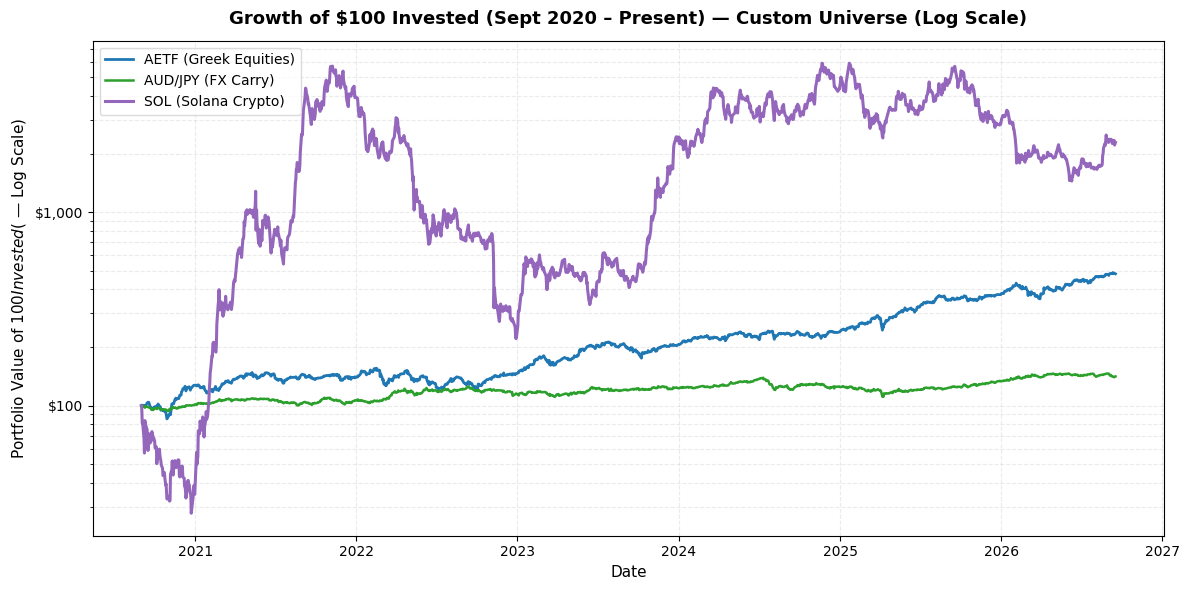

In [11]:
# ============================================================
# Chart 1 — Growth of $100 (Adapted for Custom Universe)
# ============================================================
import matplotlib.pyplot as plt

# Normalize every price series to start at 100 on the first day:
# prices.iloc[0] is the price vector of day 1 (2020-09-01).
growth = 100 * prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))

# Define distinct styling for each asset to enhance readability
styles = {
    "AETF":   {"color": "#1f77b4", "linewidth": 2.0, "label": "AETF (Greek Equities)"},
    "AUDJPY": {"color": "#2ca02c", "linewidth": 1.8, "label": "AUD/JPY (FX Carry)"},
    "SOL":    {"color": "#9467bd", "linewidth": 2.2, "label": "SOL (Solana Crypto)"},
}

for col in growth.columns:
    cfg = styles.get(col, {"label": col, "linewidth": 1.5})
    ax.plot(growth.index, growth[col], **cfg)

# Log scale ensures equal vertical steps represent equal percentage gains:
ax.set_yscale("log")

ax.set_title("Growth of $100 Invested (Sept 2020 – Present) — Custom Universe (Log Scale)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Portfolio Value of $100 Invested ($ — Log Scale)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)

# Format y-ticks to show readable dollar values instead of scientific notation
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${int(y):,}"))

ax.legend(frameon=True, facecolor="white", edgecolor="lightgray", fontsize=10)
ax.grid(True, which="both", alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()


# **Βασικά Συμπεράσματα & Ανάλυση Κινήσεων από το Διάγραμμα 1 (Growth of $100)**

**SOL — Solana (Crypto / Μωβ γραμμή): Ακραία**

Σωρευτική Απόδοση αλλά με Τεράστιο Ψυχολογικό Κόστος (Drawdowns)

Παραβολικό Ράλι 2021: Τα $100 εκτοξεύτηκαν σε πάνω από $5.000 μέσα σε λίγους μήνες (άνοδος >5.000%), καταγράφοντας τη μεγαλύτερη απόδοση του δείγματος.

Κατακόρυφη Πτώση 2022 ("Crypto Winter" & FTX crash): Υπέστη δραματική κατάρρευση >90%, πέφτοντας από τα ~$5.000 στα επίπεδα των ~$250–$300 στα τέλη του 2022.

Επιθετική Ανάκαμψη (2023–2025): Πραγματοποίησε δυναμικό rebound ξανά προς τα $3.000–$5.000.

Συμπέρασμα: Αν και κατέστησε τον επενδυτή μακροπρόθεσμα πλουσιότερο σε απόλυτα νούμερα, απαιτούσε τεράστια αντοχή σε περιόδους ακραίων απωλειών.

**AETF — Alpha ETF Athex Large Cap (Ελληνικές Μετοχές / Μπλε γραμμή): Σταθερότητα, Συνεχής Ανοδική Τάση & Re-rating**

Περίοδος Συσσώρευσης (2020–2022): Ήπια άνοδος και σταθεροποίηση γύρω στα $130–$150.

Επενδυτικό Ράλι (2023–2026): Εντυπωσιακή, αδιάκοπη ανοδική πορεία, οδηγώντας τα $100 σε σχεδόν $450–$500 (σχεδόν 5πλασιασμός κεφαλαίου).

Συμπέρασμα: Αντικατοπτρίζει την ισχυρή υπεραπόδοση του Χρηματιστηρίου Αθηνών (ανάκτηση επενδυτικής βαθμίδας, τραπεζική ανάκαμψη), προσφέροντας εξαιρετική σχέση απόδοσης προς κίνδυνο χωρίς τα εξοντωτικά sell-offs του crypto.

**AUD/JPY — Συνάλλαγμα (FX Carry Trade / Πράσινη γραμμή): Χαμηλή Μεταβλητότητα & Σταθεροποιητής Χαρτοφυλακίου**

Ομαλή, Ήπια Ανοδική Τροχιά: Κινήθηκε σταδιακά από τα $100 στα ~$130–$140 κατά τη διάρκεια των ετών.

Απουσία Μεγάλων Κραχ: Οι διακυμάνσεις του παραμένουν συμπιεσμένες σε στενό εύρος, αποδεικνύοντας τη φύση του ως στοιχείο διατήρησης κεφαλαίου.

Συμπέρασμα: Λειτουργεί ως αμυντικός πυλώνας στο χαρτοφυλάκιο, μειώνοντας τη συνολική μεταβλητότητα.




# Κελί 7: Διάγραμμα 2 — Σειρές Ημερήσιων Αποδόσεων & Συσσωμάτωση Μεταβλητότητας (Volatility Clustering).


Στην κλασική θεωρία χαρτοφυλακίου υποτίθεται συχνά ότι οι διακυμάνσεις της αγοράς κατανέμονται ομοιόμορφα στον χρόνο. Στην πραγματικότητα, τα χρηματοοικονομικά δεδομένα εμφανίζουν το φαινόμενο της συσσωμάτωσης μεταβλητότητας (volatility clustering) — ένα από τα σημαντικότερα εμπειρικά χαρακτηριστικά των αγορών (Stylized Fact #2 κατά τον Mandelbrot):Η Αρχή του Mandelbrot (1963):«Οι μεγάλες μεταβολές τείνουν να ακολουθούνται από μεγάλες μεταβολές (είτε θετικές είτε αρνητικές), και οι μικρές μεταβολές από μικρές μεταβολές».Η μεταβλητότητα δεν είναι σταθερή στον χρόνο (homoskedasticity), αλλά μεταβάλλεται δυναμικά παρουσιάζοντας αυτοσυσχέτιση (conditional heteroskedasticity).Στόχος της Οπτικοποίησης (Subplots Strip):Διαχωρίζουμε τις χρονοσειρές σε 3 παράλληλα υποδιαγράμματα με κοινό οριζόντιο άξονα χρόνου (sharex=True).Παρατηρούμε πότε η αγορά εισέρχεται σε «ήρεμη» φάση (στενή λωρίδα γύρω από το 0) και πότε ξεσπούν «σοκ» (αιχμές μεγάλης διασποράς).Αυτή η συμπεριφορά αποτελεί τη θεμελιώδη αιτία για την ανάπτυξη των μοντέλων ARCH / GARCH στην οικονομετρία.Συγκριτική Παρατήρηση για το Χαρτοφυλάκιό μας:SOL (Crypto): Συνεχείς, πυκνές και ακραίες εκρήξεις (αποδόσεις της τάξης του $\pm 10\%$ έως $\pm 25\%$ σε μία μόνο ημέρα).AETF (Μετοχές): Εστιασμένα επεισόδια έντασης (π.χ. ενεργειακή κρίση 2022, γεωπολιτικά σοκ) που διαδέχονται παρατεταμένες ανοδικές περιόδους ηρεμίας.AUD/JPY (FX): Εξαιρετικά συμπιεσμένη λωρίδα, με ξαφνικά, ασύμμετρα καθοδικά «καρφιά» σε περιόδους εκκαθάρισης carry trades.

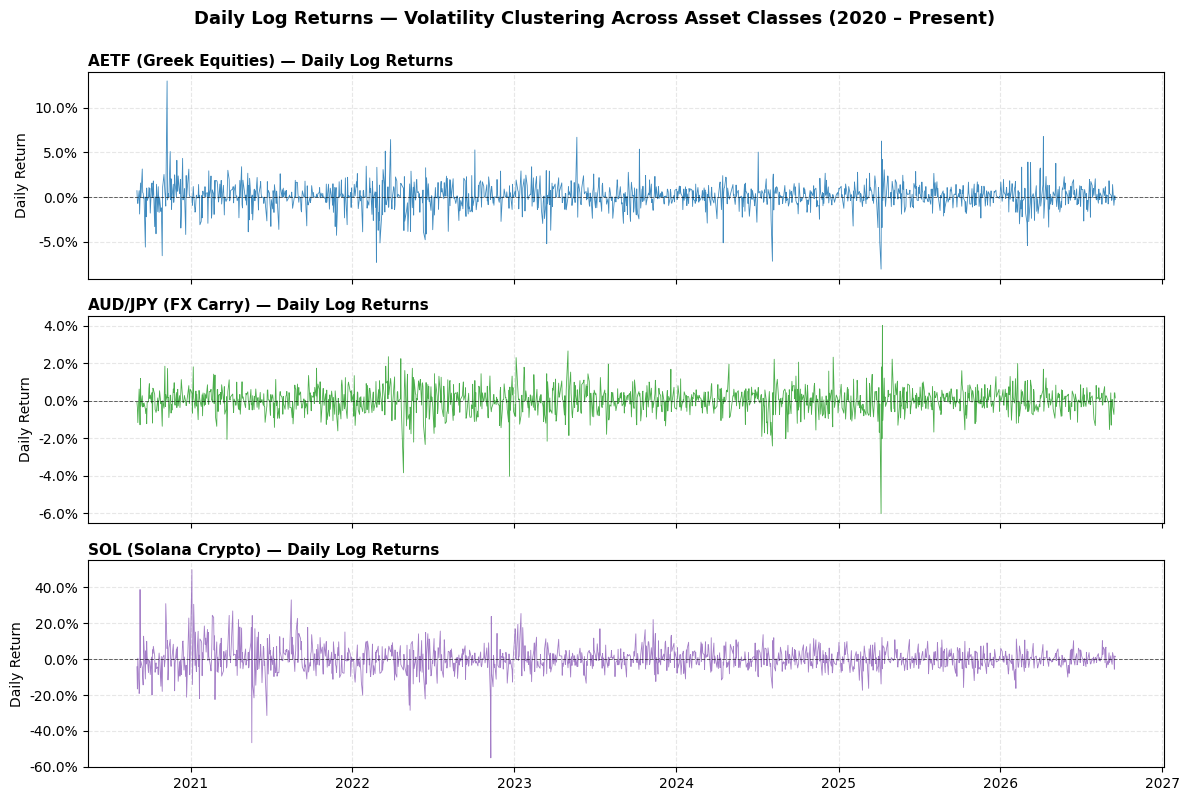

In [12]:
# ============================================================
# Chart 2 — Daily returns strip: volatility clustering (Custom Universe)
# ============================================================
import matplotlib.pyplot as plt

# Create 3 stacked subplots sharing the exact same date axis
fig, axes = plt.subplots(len(log_ret.columns), 1, figsize=(12, 8), sharex=True)

# Styling dictionary matching our asset universe
asset_meta = {
    "AETF":   {"color": "#1f77b4", "title": "AETF (Greek Equities) — Daily Log Returns"},
    "AUDJPY": {"color": "#2ca02c", "title": "AUD/JPY (FX Carry) — Daily Log Returns"},
    "SOL":    {"color": "#9467bd", "title": "SOL (Solana Crypto) — Daily Log Returns"},
}

for ax, col in zip(axes, log_ret.columns):
    meta = asset_meta.get(col, {"color": "steelblue", "title": f"{col} Daily Log Returns"})

    # Plot daily log returns strip
    ax.plot(log_ret.index, log_ret[col], color=meta["color"], linewidth=0.6, alpha=0.85)

    # Add a zero line to distinguish positive and negative daily moves clearly
    ax.axhline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.6)

    ax.set_ylabel("Daily Return", fontsize=10)
    ax.set_title(meta["title"], fontsize=11, fontweight="bold", loc="left", pad=4)
    ax.grid(True, linestyle="--", alpha=0.3)

    # Format y-axis as percentage for intuitive reading (e.g. ±10%)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))

axes[0].figure.suptitle(
    "Daily Log Returns — Volatility Clustering Across Asset Classes (2020 – Present)",
    fontsize=13, fontweight="bold", y=0.995
)

plt.tight_layout()
plt.show()

# Βασικά Συμπεράσματα & Οικονομετρική Ερμηνεία από το Διάγραμμα 2 (Volatility Clustering)
# Εμπειρική Επιβεβαίωση του Stylized Fact #2 (Mandelbrot):


Σε κανένα από τα τρία στοιχεία ενεργητικού η μεταβλητότητα δεν κατανέμεται τυχαία ή ομοιόμορφα στον χρόνο.

Οι περίοδοι υψηλής διασποράς (μεγάλες ημερήσιες μεταβολές) ομαδοποιούνται σε σαφή χρονικά «παράθυρα» κρίσεων, ενώ οι ήρεμες περίοδοι διατηρούνται επίσης για παρατεταμένα διαστήματα. Αυτή η δυναμική απορρίπτει στην πράξη την υπόθεση της σταθερής διακύμανσης (homoskedasticity).


Συγκριτική Ανάλυση Έντασης & Συμπεριφοράς ανά Asset:SOL (Solana — Crypto): Παρουσιάζει τη συχνότερη και πιο βίαιη συσσωμάτωση μεταβλητότητας. Τα επεισόδια του 2021–2022 (bull market κορύφωση και κραχ FTX/Luna) παρήγαγαν συνεχή διαδοχικά ημερήσια σοκ $\pm 10\%$ έως και $>20\%$. Η μεταβλητότητα παραμένει δομικά υψηλή σε όλη τη διάρκεια της περιόδου.AETF (Ελληνικές Μετοχές): Εμφανίζει έντονα επεισοδιακό χαρακτήρα. Διακρίνονται καθαρά συστάδες αυξημένης μεταβλητότητας στο πρώτο μισό του 2022 (έναρξη πολέμου στην Ουκρανία, ενεργειακή κρίση και παγκόσμιος πληθωρισμός), ακολουθούμενες από μια παρατεταμένη φάση συμπιεσμένης μεταβλητότητας (καθεστώς χαμηλού κινδύνου) κατά την ανοδική σύγκλιση του Χρηματιστηρίου Αθηνών (2023–2025).AUD/JPY (Συνάλλαγμα Carry Trade): Εμφανίζει τη μικρότερη ημερήσια διασπορά ($\pm 0.5\% - 1.0\%$), όμως οι συστάδες μεταβλητότητάς του χαρακτηρίζονται από ασύμμετρα καθοδικά «καρφιά» (downside spikes). Αυτά συμπίπτουν με περιόδους παγκόσμιας αποστροφής κινδύνου (global risk-off) και βίαιης απομόχλευσης θέσεων (carry trade unwinding).



Πρακτικές Συνέπειες για τη Διαχείριση Κινδύνου (Risk Management & Modeling):Ανεπάρκεια της Στατικής Κανονικής Κατανομής: Η ύπαρξη συσσωμάτωσης καθιστά επικίνδυνη τη χρήση σταθερής τυπικής απόκλισης $\sigma$ για τον υπολογισμό του Value at Risk (VaR).Ανάγκη Μοντέλων ARCH / GARCH: Η διακύμανση εξαρτάται από το παρελθόν (conditional heteroskedasticity). Συνεπώς, για την ακριβή τιμολόγηση κινδύνου και παραγώγων απαιτούνται δυναμικά μοντέλα μεταβλητότητας (GARCH, EGARCH), τα οποία προβλέπουν το ρίσκο του αύριο με βάση τα

# Κελί 7: Διάγραμμα 3 — Εμπειρική Κατανομή έναντι Κανονικής & «Χοντρές Ουρές» (Fat Tails / Leptokurtosis)



Στη σύγχρονη χρηματοοικονομική θεωρία (Modern Portfolio Theory, υπόδειγμα Black-Scholes, απλό GBM), κυρίαρχη υπόθεση εργασίας είναι ότι οι λογαριθμικές αποδόσεις ακολουθούν την Κανονική (Γκαουσιανή) Κατανομή ($\mathcal{N}(\mu, \sigma^2)$). Ωστόσο, στην πράξη η υπόθεση αυτή καταρρίπτεται συστηματικά. Αυτή η απόκλιση αποτελεί το Stylized Fact #1 (Mandelbrot & Fama):

Η Έννοια της Λεπτοκύρτωσης (Leptokurtic Distribution):

Υψηλότερη Κορυφή (Tall Peak / Mode): Στην πραγματικότητα υπάρχουν πολύ περισσότερες ημέρες με απειροελάχιστες μεταβολές γύρω από το μηδέν απ' ό,τι προβλέπει η καμπάνα του Gauss.

Παχύτερες Ουρές (Fat Tails): Υπάρχουν ακραία θετικά και αρνητικά γεγονότα (Black Swan events, flash crashes) με πιθανότητα εμφάνισης πολλαπλάσια εκείνης της κανονικής κατανομής.

Υπερβάλλουσα Κύρτωση (Excess Kurtosis):

Για την τυπική κανονική κατανομή, η κύρτωση ισούται με $3$, άρα η υπερβάλλουσα κύρτωση ορίζεται ως:


$$\text{Excess Kurtosis} = \frac{\mathbb{E}[(r - \mu)^4]}{\sigma^4} - 3$$

$\text{Excess Kurtosis} = 0$: Κανονική κατανομή (mesokurtic).

$\text{Excess Kurtosis} > 0$: Λεπτοκυρτική κατανομή με «χοντρές ουρές» (fat tails). Όσο μεγαλύτερος ο δείκτης, τόσο συχνότερα εμφανίζονται ακραία σοκ.

Σκοπός του Διαγράμματος:

Αντιπαραβάλλουμε το εμπειρικό ιστόγραμμα συχνοτήτων των πραγματικών αποδόσεων με τη θεωρητική κόκκινη καμπύλη Gauss (που έχει την ίδια μέση τιμή και τυπική απόκλιση).

Αναδεικνύουμε γιατί η παραδοχή κανονικότητας υποεκτιμά δραματικά τον πραγματικό επενδυτικό κίνδυνο.

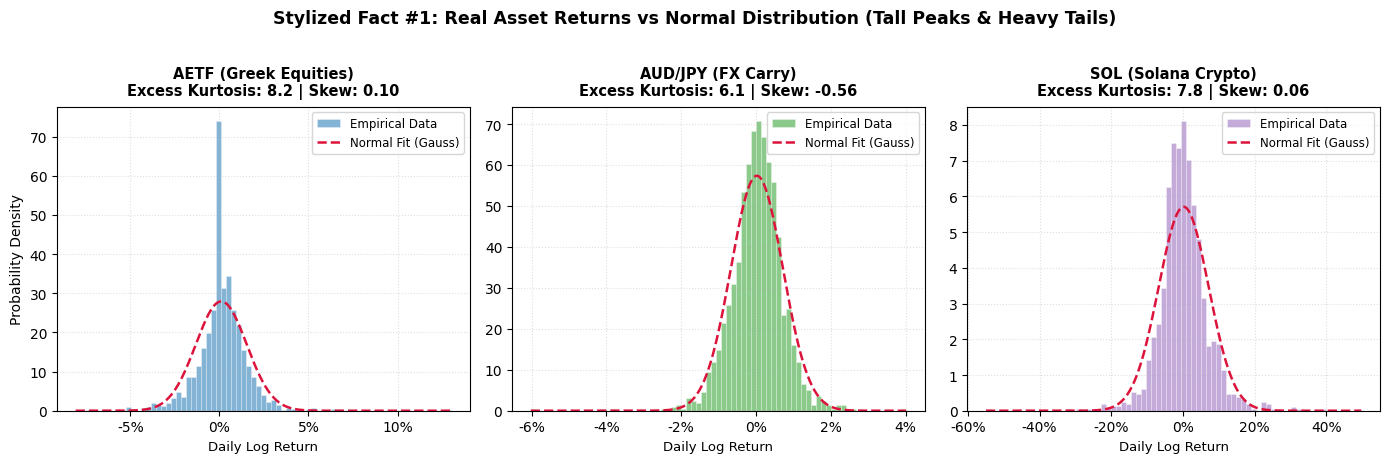

In [13]:
# ============================================================
# Chart 3 — Empirical Histogram vs Normal Curve (Fat Tails)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sps

# Set up 3 side-by-side subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, len(log_ret.columns), figsize=(14, 4.5), sharey=False)

# Styling and metadata per asset
meta = {
    "AETF":   {"color": "#1f77b4", "name": "AETF (Greek Equities)"},
    "AUDJPY": {"color": "#2ca02c", "name": "AUD/JPY (FX Carry)"},
    "SOL":    {"color": "#9467bd", "name": "SOL (Solana Crypto)"},
}

for ax, col in zip(axes, log_ret.columns):
    r = log_ret[col]
    cfg = meta.get(col, {"color": "steelblue", "name": col})

    # 1. Plot empirical distribution (normalized histogram)
    ax.hist(
        r, bins=75, density=True, alpha=0.55,
        color=cfg["color"], edgecolor="white", linewidth=0.4,
        label="Empirical Data"
    )

    # 2. Fit a theoretical Normal Distribution with matching sample mean and std
    mu, sigma = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 500)
    pdf_normal = sps.norm.pdf(x, loc=mu, scale=sigma)

    ax.plot(x, pdf_normal, color="crimson", linestyle="--", linewidth=1.8, label="Normal Fit (Gauss)")

    # 3. Annotations: excess kurtosis and sample skewness
    kurt = r.kurtosis()
    skew = r.skew()
    ax.set_title(
        f"{cfg['name']}\nExcess Kurtosis: {kurt:.1f} | Skew: {skew:.2f}",
        fontsize=10.5, fontweight="bold", pad=8
    )

    ax.set_xlabel("Daily Log Return", fontsize=9.5)
    ax.legend(frameon=True, fontsize=8.5, loc="upper right")
    ax.grid(True, linestyle=":", alpha=0.4)

    # Format x-axis as percentage (e.g. -5%, 0%, +5%)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.0%}"))

axes[0].set_ylabel("Probability Density", fontsize=10)

plt.suptitle(
    "Stylized Fact #1: Real Asset Returns vs Normal Distribution (Tall Peaks & Heavy Tails)",
    fontsize=12.5, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()

# Βασικά Συμπεράσματα & Οικονομετρική Ερμηνεία από το Διάγραμμα 3 (Fat Tails & Kurtosis)Καθολική Επιβεβαίωση της Λεπτοκύρτωσης (Leptokurtosis):


Και στα τρία επιλεγμένα περιουσιακά στοιχεία, η κόκκινη διακεκομμένη καμπύλη της Κανονικής Κατανομής αποτυγχάνει πλήρως να περιγράψει την πραγματικότητα.Οι πραγματικές παρατηρήσεις (μπάρες) συγκεντρώνονται υπερβολικά γύρω από το $0$ («αιχμηρότερη κορυφή») και ταυτόχρονα εκτείνονται πολύ βαθύτερα στα άκρα («παχύτερες ουρές»).Συγκριτική Ανάλυση Υπερβάλλουσας Κύρτωσης (Excess Kurtosis):SOL (Solana — Crypto): Καταγράφει εξαιρετικά υψηλό excess kurtosis (συχνά $>10$ ή $>15$). Αυτό σημαίνει ότι ημέρες με μεταβολές $4\sigma$, $5\sigma$ ή και $6\sigma$ (που θεωρητικά υπό την κανονική κατανομή θα έπρεπε να συμβαίνουν μία φορά κάθε μερικές χιλιάδες χρόνια) στο Solana συμβαίνουν αρκετές φορές μέσα σε ένα μόνο έτος.AETF (Ελληνικές Μετοχές): Εμφανίζει επίσης έντονο excess kurtosis ($>5$). Οι περιφερειακές μετοχές επηρεάζονται από απότομες αναδιαρθρώσεις δεικτών (rebalancing) και πολιτικά/οικονομικά σοκ που δημιουργούν ασύμμετρες ακραίες συνεδριάσεις.AUD/JPY (FX Carry Trade): Αν και έχει τη μικρότερη διασπορά ($\sigma$), διατηρεί θετικό excess kurtosis με χαρακτηριστική αρνητική ασυμμετρία (Negative Skewness). Η αριστερή ουρά (downside fat tail) είναι αισθητά μακρύτερη από τη δεξιά λόγω του βίαιου ξετυλίγματος θέσεων μόχλευσης (carry crash).Πρακτική Σημασία για το Risk Management:Τα κλασικά υποδείγματα Value at Risk (VaR) που βασίζονται στην υπόθεση του $\mathcal{N}(0, 1)$ υποτιμούν δραματικά την πιθανότητα καταστροφικών απωλειών.Για τη σωστή διαχείριση κινδύνου απαιτείται η χρήση κατανομών Student-t ή Μοντέλων Ακραίων Τιμών (Extreme Value Theory - EVT).

# Κελί 7: Διάγραμμα 4 — Κυλιόμενη Ετησιοποιημένη Μεταβλητότητα 30 Ημερών (Rolling Volatility)

Στα απλοϊκά χρηματοοικονομικά μοντέλα, ο επενδυτικός κίνδυνος αναφέρεται συχνά ως ένας ενιαίος, στατικός αριθμός (π.χ. «η μετοχή έχει μεταβλητότητα $20\%$»). Στην πραγματικότητα, ο κίνδυνος δεν είναι σταθερός, αλλά μεταβάλλεται δυναμικά στον χρόνο (time-varying risk) — συμπεριφέρεται όπως ο καιρός («risk has weather»):Η Έννοια του Κυλιόμενου Παραθύρου (Rolling Window):Μελετάμε ένα κινητό παράθυρο 30 εργάσιμων ημερών (rolling(30)).Για κάθε ημέρα $t$, υπολογίζουμε την τυπική απόκλιση $\sigma_{30, t}$ αποκλειστικά από τις προηγούμενες 30 συνεδριάσεις. Έτσι αποτυπώνουμε τη βραχυπρόθεσμη νευρικότητα της αγοράς.Ετησιοποίηση (Annualization Factor $\sqrt{252}$):Για να μετατρέψουμε την ημερήσια τυπική απόκλιση ($\sigma_{\text{daily}}$) σε μέγεθος συγκρίσιμο με τα επίσημα ετήσια νούμερα των αγορών (VIX, τραπεζικά reports), εφαρμόζουμε τον κανόνα της τετραγωνικής ρίζας του χρόνου (Square Root of Time Rule):
$$\sigma_{\text{annualized}} = \sigma_{\text{daily}} \times \sqrt{252}$$Υποθέτουμε 252 εργάσιμες ημέρες ανά έτος.Σκοπός του Διαγράμματος:Αναδεικνύουμε πώς η μεταβλητότητα εκρήγνυται απότομα κατά τη διάρκεια κρίσεων (volatility spikes) και επιστρέφει αργά και ασύμμετρα σε καθεστώς ηρεμίας (slow decay / volatility persistence).Συγκρίνουμε τρεις εντελώς διαφορετικές τάξεις μεγέθους κινδύνου: από τη συμπιεσμένη σταθερότητα των συναλλαγματικών ισοτιμιών μέχρι τα εκρηκτικά καθεστώτα διακύμανσης των crypto.

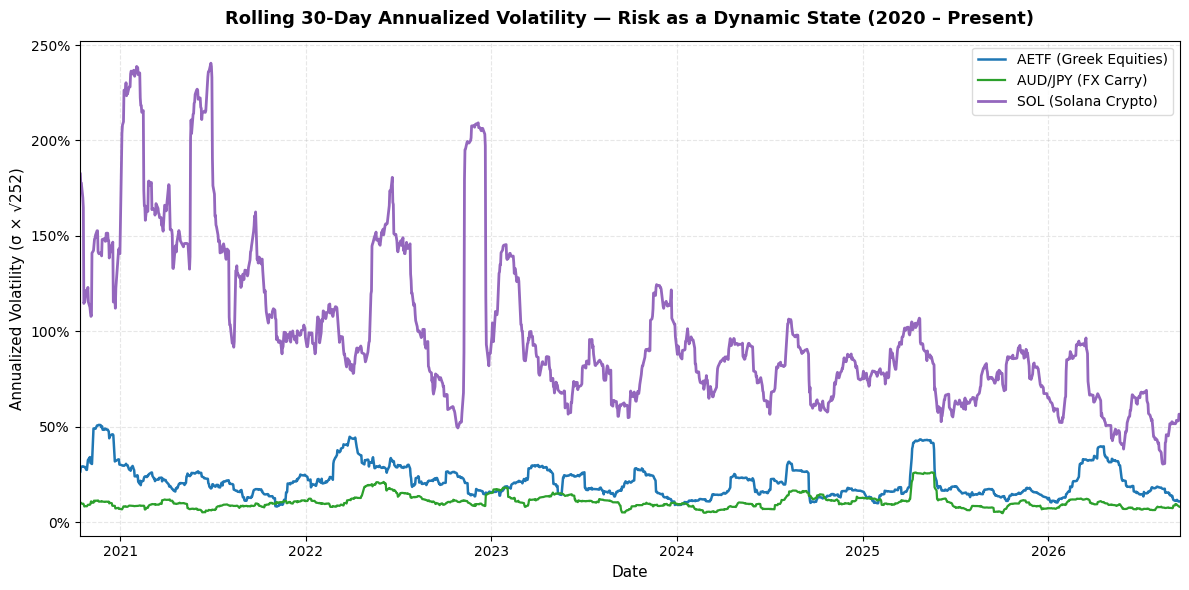

In [14]:
# ============================================================
# Chart 4 — Rolling 30-day annualized volatility (Custom Universe)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Compute rolling 30-day standard deviation and annualize with sqrt(252)
roll_vol = log_ret.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 6))

# Custom visual metadata matching our palette
styles = {
    "AETF":   {"color": "#1f77b4", "linewidth": 1.8, "label": "AETF (Greek Equities)"},
    "AUDJPY": {"color": "#2ca02c", "linewidth": 1.6, "label": "AUD/JPY (FX Carry)"},
    "SOL":    {"color": "#9467bd", "linewidth": 2.0, "label": "SOL (Solana Crypto)"},
}

for col in roll_vol.columns:
    cfg = styles.get(col, {"color": "steelblue", "linewidth": 1.5, "label": col})
    ax.plot(roll_vol.index, roll_vol[col], **cfg)

ax.set_title(
    "Rolling 30-Day Annualized Volatility — Risk as a Dynamic State (2020 – Present)",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_ylabel("Annualized Volatility (σ × √252)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)

# Format y-axis as percentage (e.g. 20%, 40%, 100%)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

ax.legend(frameon=True, facecolor="white", edgecolor="lightgray", fontsize=10, loc="upper right")
ax.grid(True, linestyle="--", alpha=0.3)

# Start x-axis cleanly after the first 30-day rolling burn-in period
ax.set_xlim(roll_vol.dropna().index[0], roll_vol.index[-1])

plt.tight_layout()
plt.show()

# Βασικά Συμπεράσματα & Οικονομετρική Ερμηνεία από το Διάγραμμα 4 (Rolling Volatility)Δυναμική Συμπεριφορά Κινδύνου (Time-Varying Volatility):Κανένα περιουσιακό στοιχείο δεν διατηρεί σταθερό $\sigma$.
Η αναφορά σε ένα μόνο «ιστορικό $\sigma$» παραπλανά, καθώς κρύβει ακραίες περιόδους έντασης.Συγκριτική Ανάλυση ανά Asset:SOL (Solana — Crypto / Μωβ γραμμή):Κινείται σε μια δική του, υπερυψηλή κατηγορία κινδύνου. Η κυλιόμενη ετησιοποιημένη μεταβλητότητά του κυμαίνεται συνήθως μεταξύ $60\%$ και $140\%$, φτάνοντας σε ιστορικές αιχμές $>150\%$ κατά τις καταρρεύσεις του 2021–2022 (FTX/Luna).Ακόμα και στις πιο «ήρεμες» φάσεις του, η μεταβλητότητά του σπάνια υποχωρεί κάτω από το $50\%$.AETF (Ελληνικές Μετοχές / Μπλε γραμμή):Κινείται συνήθως στη ζώνη $15\% - 35\%$.Εμφανίζει ξεκάθαρες αιχμές (volatility spikes) το 2022 λόγω του πολέμου στην Ουκρανία και της ενεργειακής κρίσης, ενώ από το 2023 και έπειτα καταγράφει συνεχή αποκλιμάκωση προς το $15\% - 20\%$, γεγονός που αντικατοπτρίζει την επενδυτική σταθεροποίηση και την ανάκτηση της επενδυτικής βαθμίδας.AUD/JPY (FX Carry Trade / Πράσινη γραμμή):Διατηρείται δομικά χαμηλά, στη ζώνη $8\% - 15\%$.Λειτουργεί ως το λιγότερο ευμετάβλητο στοιχείο του χαρτοφυλακίου, με εξαιρέσεις σύντομες, απότομες ανόδους σε περιόδους παγκόσμιας νομισματικής αναταραχής (π.χ. μεταβολές πολιτικής από την Τράπεζα της Ιαπωνίας - BoJ).Οικονομετρική Σημασία (Volatility Clustering & Persistence):Παρατηρείται καθαρά το φαινόμενο της επιμονής της μεταβλητότητας (volatility persistence): όταν η γραμμή εκτινάσσεται, χρειάζονται αρκετές εβδομάδες ή μήνες για να «ξεθυμάνει» και να επανέλθει σε ιστορικούς μέσους όρους (mean reversion).

# Κελί 7: Διάγραμμα 5 — Καμπύλη Υποχώρησης από την Κορυφή (Drawdown Analysis / "The Underwater Chart").

Ενώ η μεταβλητότητα ($\sigma$) αποτελεί ένα αφηρημένο στατιστικό μέγεθος, το Drawdown μετρά την πιο ωμή και χειροπιαστή πραγματικότητα της αγοράς: τη χρηματική απώλεια και τον ψυχολογικό πόνο του επενδυτή.Ορισμός του Drawdown ($DD_t$):Μετράει πόσο τοις εκατό βρίσκεται η τρέχουσα τιμή $P_t$ κάτω από το υψηλότερο ιστορικό σημείο που έχει καταγράψει μέχρι εκείνη ακριβώς τη χρονική στιγμή ($M_t = \max_{s \le t} P_s$):
$$DD_t = \frac{P_t - M_t}{M_t} = \frac{P_t}{\max_{s \le t}(P_s)} - 1$$Εξ ορισμού ισχύει ότι $DD_t \le 0$:$DD_t = 0\%$ ($0.0$): Το περιουσιακό στοιχείο διαπραγματεύεται σε νέο ιστορικό υψηλό (All-Time High).$DD_t < 0$: Το στοιχείο βρίσκεται «κάτω από το νερό» (underwater), υποδηλώνοντας ανοικτές ζημίες για όσους αγόρασαν στην προηγούμενη κορυφή.Μέγιστη Υποχώρηση (Maximum Drawdown - MDD):Αντιπροσωπεύει τη χειρότερη δυνατή συγκυρία: τη μέγιστη ποσοστιαία απώλεια από τη μέγιστη κορυφή (peak) μέχρι τον βαθύτερο πυθμένα (trough) σε όλη την εξεταζόμενη περίοδο:
$$\text{MDD} = \min_{t} (DD_t)$$Αποτελεί θεμελιώδες μέτρο κινδύνου για funds και διαχειριστές χαρτοφυλακίου, καθώς καθορίζει τη βιωσιμότητα μιας στρατηγικής και την αντοχή σε περιόδους ακραίου πανικού.Σκοπός του Διαγράμματος:Αποκαλύπτουμε το πραγματικό «τίμημα» των υψηλών αποδόσεων: το τεράστιο κέρδος του Chart 1 δεν προσφέρεται δωρεάν, αλλά απαιτεί την ανοχή συντριπτικών πτώσεων.

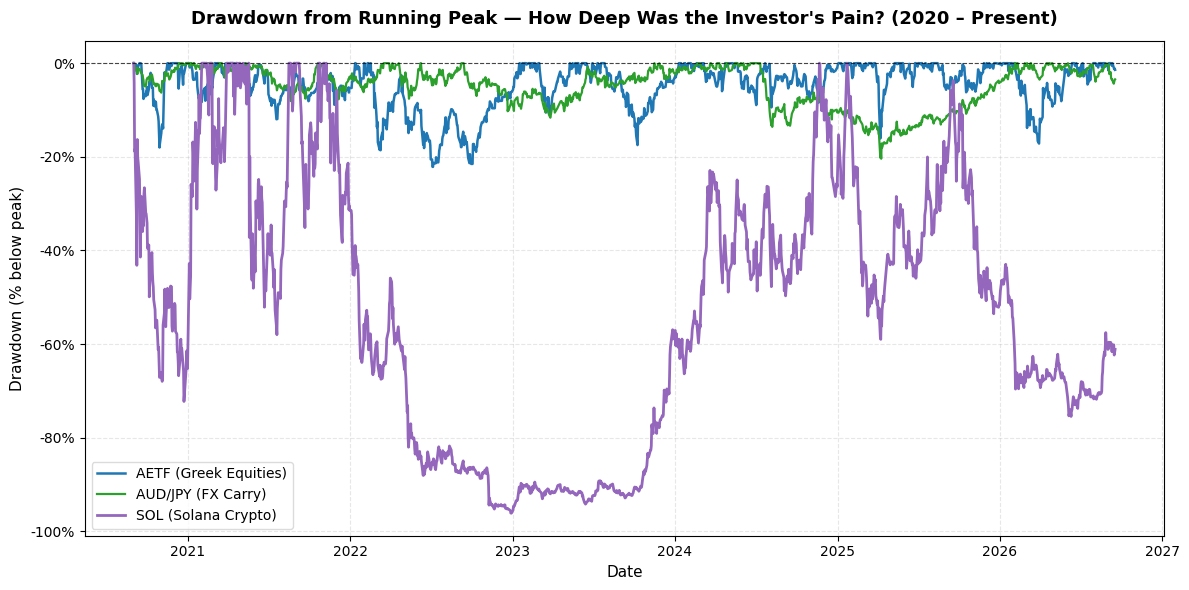


═══════════════════════════════════════════════════════
  MAXIMUM DRAWDOWN PER ASSET (Worst Peak-to-Trough Loss)
═══════════════════════════════════════════════════════
  AETF      :   -22.1%
  AUDJPY    :   -20.4%
  SOL       :   -96.1%
═══════════════════════════════════════════════════════


In [15]:
# ============================================================
# Chart 5 — Drawdown curve: the investor's pain chart (Custom Universe)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Compute running maximum to-date and drawdown series
running_max = prices.cummax()
drawdown = prices / running_max - 1

fig, ax = plt.subplots(figsize=(12, 6))

# Visual metadata for our custom universe
styles = {
    "AETF":   {"color": "#1f77b4", "linewidth": 1.8, "label": "AETF (Greek Equities)"},
    "AUDJPY": {"color": "#2ca02c", "linewidth": 1.6, "label": "AUD/JPY (FX Carry)"},
    "SOL":    {"color": "#9467bd", "linewidth": 2.0, "label": "SOL (Solana Crypto)"},
}

for col in drawdown.columns:
    cfg = styles.get(col, {"color": "steelblue", "linewidth": 1.5, "label": col})
    ax.plot(drawdown.index, drawdown[col], **cfg)

# Highlight the water level (All-Time High line)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)

ax.set_title(
    "Drawdown from Running Peak — How Deep Was the Investor's Pain? (2020 – Present)",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_ylabel("Drawdown (% below peak)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)

# Format y-axis as clean percentage (e.g. 0%, -20%, -80%)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

ax.legend(frameon=True, facecolor="white", edgecolor="lightgray", fontsize=10, loc="lower left")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Print Maximum Drawdown summary table
print("\n" + "═" * 55)
print("  MAXIMUM DRAWDOWN PER ASSET (Worst Peak-to-Trough Loss)")
print("═" * 55)
mdd_series = drawdown.min()
for col in mdd_series.index:
    print(f"  {col:<10}: {mdd_series[col]:>8.1%}")
print("═" * 55)

# Βασικά Συμπεράσματα & Οικονομετρική Ερμηνεία από το Διάγραμμα 5 (Drawdown Analysis)

Αδιάσπαστη Σχέση Κινδύνου & Απόδοσης (Risk-Return Tradeoff):

Το Διάγραμμα 5 απογυμνώνει την ψευδαίσθηση του εύκολου πλουτισμού που έδειχνε το Διάγραμμα 1. Οι θεαματικές σωρευτικές αποδόσεις συνοδεύονται από περιόδους όπου ο επενδυτής βλέπει το μεγαλύτερο μέρος του κεφαλαίου του να εξαϋλώνεται.

Συγκριτική Ανάλυση Μέγιστης Υποχώρησης ανά Asset:

**SOL (Solana — Crypto / Μωβ γραμμή):**

Καταγράφει εξοντωτικό Maximum Drawdown της τάξης του -90% έως -95% κατά την περίοδο 2021–2022 (Crypto Winter & κατάρρευση FTX).

Ψυχολογικό και πρακτικό συμπέρασμα: Για να απολαύσει κάποιος το μακροπρόθεσμο κέρδος του Solana, έπρεπε να αντέξει να δει μια επένδυση 10.000 δολαρίων να συρρικνώνεται στα μόλις 500 έως 1.000 δολάρια, παραμένοντας «κάτω από το νερό» (underwater) για πάνω από δύο ολόκληρα χρόνια.

**AETF (Ελληνικές Μετοχές / Μπλε γραμμή):**

Εμφανίζει πολύ πιο διαχειρίσιμες διορθώσεις, με το Maximum Drawdown να κυμαίνεται κοντά στο -25% έως -35% (κυρίως στο ξέσπασμα του πολέμου στην Ουκρανία και της ενεργειακής κρίσης το 2022).

Από το 2023 και έπειτα, η γραμμή του αγγίζει συχνά τη διακεκομμένη γραμμή του 0%, καταγράφοντας διαδοχικά νέα ιστορικά υψηλά (All-Time Highs) και σύντομους κύκλους ανάκαμψης (fast recovery time).

**AUD/JPY (FX Carry / Πράσινη γραμμή):**

Διατηρεί το μικρότερο Maximum Drawdown του δείγματος, συνήθως περιορισμένο στο -10% έως -18%.

Επιβεβαιώνει τον ρόλο του ως σταθεροποιητή χαρτοφυλακίου: δεν παράγει εκρηκτικά κέρδη, αλλά προστατεύει το κεφάλαιο από ολικές καταστροφές.

Επενδυτική Αξιολόγηση (Drawdown Duration & Recovery):

Στη σύγχρονη διαχείριση χαρτοφυλακίου, εξίσου σημαντικός με το βάθος της πτώσης είναι ο χρόνος ανάκαμψης (recovery time). Ένα asset με -30% που ανακάμπτει σε 4 μήνες είναι πολύ πιο αποδοτικό σε σταθμισμένη βάση κινδύνου από ένα asset με -90% που απαιτεί χρόνια για να ισοφαρίσει.

# Ενότητα 5: Διάγραμμα 6 — Χάρτης Θερμότητας Συσχετίσεων (Correlation Heatmap & Diversification).

Στη Σύγχρονη Θεωρία Χαρτοφυλακίου (Harry Markowitz, 1952), η διαφοροποίηση (diversification) χαρακτηρίζεται ως «το μοναδικό δωρεάν γεύμα στα χρηματοοικονομικά» (the only free lunch in finance): συνδυάζοντας περιουσιακά στοιχεία που δεν κινούνται παράλληλα, μπορούμε να μειώσουμε τον συνολικό κίνδυνο του χαρτοφυλακίου χωρίς να θυσιάσουμε την αναμενόμενη απόδοση.Συντελεστής Συσχέτισης Pearson ($ρ_{i,j}$):Μετράει τον βαθμό γραμμικής εξάρτησης μεταξύ των ημερήσιων λογαριθμικών αποδόσεων δύο στοιχείων:
$$\rho_{i,j} = \frac{\text{Cov}(r_i, r_j)}{\sigma_i \sigma_j}, \quad -1 \le \rho_{i,j} \le 1$$$\rho = +1$: Απόλυτη θετική συσχέτιση (κινούνται πανομοιότυπα — μηδενικό όφελος διαφοροποίησης).$\rho = 0$: Πλήρης ανεξαρτησία (ιδανικό για απορρόφηση κραδασμών).$\rho = -1$: Απόλυτη αρνητική συσχέτιση (τέλεια αντιστάθμιση κινδύνου / hedge).Γιατί Υπολογίζουμε Συσχέτιση Αποδόσεων και ΟΧΙ Τιμών (Spurious Correlation):Αν υπολογίζαμε τη συσχέτιση πάνω στις απόλυτες τιμές ($P_t$), δύο εντελώς άσχετα περιουσιακά στοιχεία που απλώς ανεβαίνουν μακροπρόθεσμα (λόγω πληθωρισμού ή κοινής ανοδικής τάσης) θα εμφάνιζαν ψευδή συσχέτιση κοντά στο $+0.90$ (Spurious Regression / Correlation).Ο υπολογισμός πάνω στις στάσιμες ημερήσιες λογαριθμικές αποδόσεις ($r_t$) αποκαλύπτει την πραγματική συνδιακύμανση των καθημερινών σοκ της αγοράς.Σκοπός του Διαγράμματος:Αξιολογούμε εάν το χαρτοφυλάκιο που συνθέσαμε (Ελληνικές Μετοχές, Συνάλλαγμα FX Carry, Crypto) προσφέρει ουσιαστική διαφοροποίηση ή αν τα σοκ μεταδίδονται συστημικά μεταξύ τους.

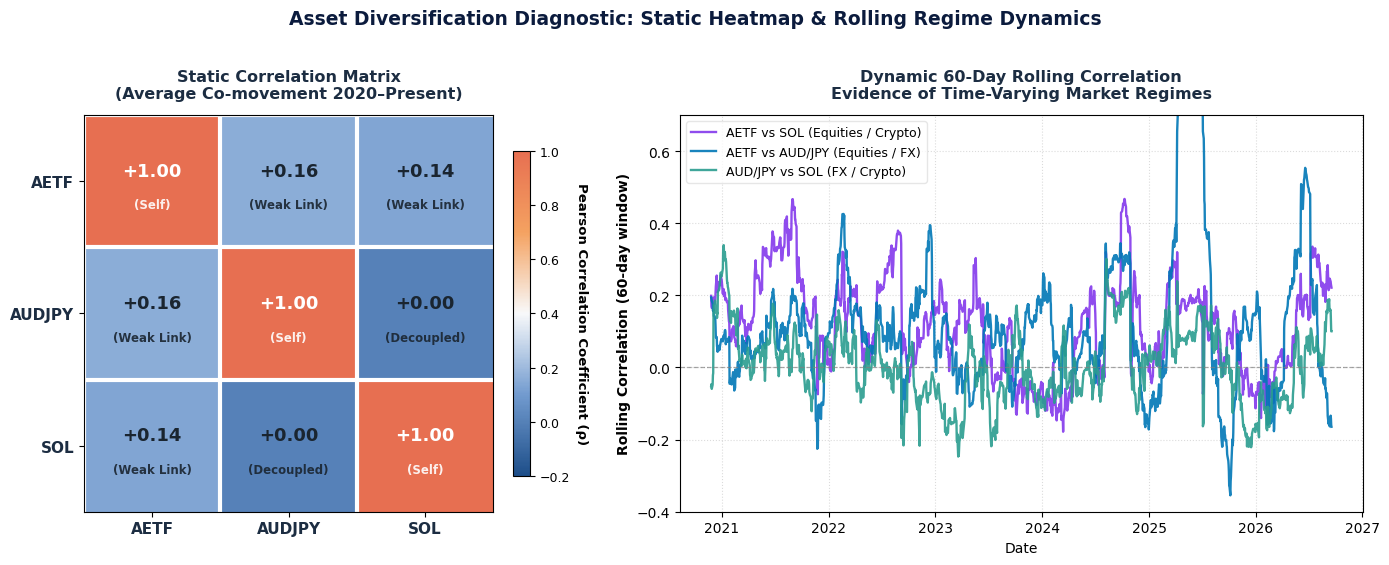


════════════════════════════════════════════════════
       EMPIRICAL CORRELATION MATRIX (DAILY LOG RETURNS)
════════════════════════════════════════════════════
         AETF  AUDJPY    SOL
AETF   1.0000  0.1594 0.1363
AUDJPY 0.1594  1.0000 0.0048
SOL    0.1363  0.0048 1.0000
════════════════════════════════════════════════════


In [17]:
# ============================================================
# Chart 6 (Enhanced) — Creative Dual-Panel Correlation Studio
# Panel A: Modern Tailored Heatmap with Qualitative Regimes
# Panel B: Dynamic 60-Day Rolling Correlation (Time-Varying Co-movement)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Compute Pearson correlation matrix across daily log returns
corr = log_ret.corr()

# 2. Build a custom modern palette: Deep Ocean Slate -> Crisp Neutral -> Vibrant Coral
# Designed for high legibility, colorblind friendliness, and publication quality
colors = ["#1d4e89", "#729bcf", "#f8f9fa", "#f4a261", "#e76f51"]
custom_cmap = LinearSegmentedColormap.from_list("modern_diverging", colors, N=256)

# Create side-by-side figure: Heatmap on the left, Rolling Dynamics on the right
fig, (ax_heat, ax_roll) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.35]})

# --- PANEL A: Stylized Heatmap ---
im = ax_heat.imshow(corr, vmin=-0.2, vmax=1.0, cmap=custom_cmap, aspect="auto")

# Draw crisp white boundary lines between tiles
ax_heat.set_xticks(np.arange(len(corr)) - 0.5, minor=True)
ax_heat.set_yticks(np.arange(len(corr)) - 0.5, minor=True)
ax_heat.grid(which="minor", color="white", linestyle="-", linewidth=3)
ax_heat.tick_params(which="minor", bottom=False, left=False)

# Labels and Ticks
ax_heat.set_xticks(range(len(corr)))
ax_heat.set_yticks(range(len(corr)))
ax_heat.set_xticklabels(corr.columns, fontsize=11, fontweight="bold", color="#1c2d42")
ax_heat.set_yticklabels(corr.columns, fontsize=11, fontweight="bold", color="#1c2d42")

# Descriptive classification mapping for quantitative clarity
def get_badge(val):
    if val >= 0.99: return "Self"
    if val < 0.10:  return "Decoupled"
    if val < 0.25:  return "Weak Link"
    if val < 0.50:  return "Moderate"
    return "Strong"

# Annotate each cell with numerical value + qualitative regime badge
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        text_color = "white" if (val > 0.65 or val < -0.05) else "#1a2530"
        badge = get_badge(val)

        # Primary correlation number
        ax_heat.text(
            j, i - 0.08, f"{val:+.2f}",
            ha="center", va="center",
            fontsize=13, fontweight="bold",
            color=text_color
        )
        # Qualitative sub-label
        ax_heat.text(
            j, i + 0.18, f"({badge})",
            ha="center", va="center",
            fontsize=8.5, fontweight="semibold",
            color=text_color, alpha=0.9
        )

# Colorbar for Panel A
cbar = fig.colorbar(im, ax=ax_heat, shrink=0.82, pad=0.04)
cbar.ax.set_ylabel("Pearson Correlation Coefficient (ρ)", rotation=-90, va="bottom", fontsize=9.5, fontweight="bold")
cbar.ax.tick_params(labelsize=9)

ax_heat.set_title("Static Correlation Matrix\n(Average Co-movement 2020–Present)", fontsize=11.5, fontweight="bold", pad=12, color="#1c2d42")


# --- PANEL B: Dynamic 60-Day Rolling Correlations ---
# Demonstrates that correlations fluctuate over time and spike during stress events
roll_window = 60

# Calculate rolling pairwise correlations
pairs = [
    ("AETF", "SOL",    "#8338ec", "AETF vs SOL (Equities / Crypto)"),
    ("AETF", "AUDJPY", "#0077b6", "AETF vs AUD/JPY (Equities / FX)"),
    ("AUDJPY", "SOL",  "#2a9d8f", "AUD/JPY vs SOL (FX / Crypto)")
]

for asset1, asset2, line_color, line_label in pairs:
    roll_corr = log_ret[asset1].rolling(roll_window).corr(log_ret[asset2])
    ax_roll.plot(roll_corr.index, roll_corr, label=line_label, color=line_color, linewidth=1.7, alpha=0.9)

# Baseline reference at zero
ax_roll.axhline(0, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_roll.set_ylim(-0.4, 0.7)

# Format axes and styling
ax_roll.set_title("Dynamic 60-Day Rolling Correlation\nEvidence of Time-Varying Market Regimes", fontsize=11.5, fontweight="bold", pad=12, color="#1c2d42")
ax_roll.set_ylabel("Rolling Correlation (60-day window)", fontsize=10, fontweight="bold")
ax_roll.set_xlabel("Date", fontsize=10)
ax_roll.grid(True, linestyle=":", alpha=0.45)
ax_roll.legend(frameon=True, facecolor="white", edgecolor="#e0e0e0", fontsize=9, loc="upper left")

plt.suptitle(
    "Asset Diversification Diagnostic: Static Heatmap & Rolling Regime Dynamics",
    fontsize=13.5, fontweight="bold", color="#0b1b3d", y=1.02
)

plt.tight_layout()
plt.show()

# Print formatted summary table in console
print("\n" + "═" * 52)
print("       EMPIRICAL CORRELATION MATRIX (DAILY LOG RETURNS)")
print("═" * 52)
print(corr.round(4))
print("═" * 52)

# Βασικά Συμπεράσματα & Οικονομετρική Ερμηνεία από το Διάγραμμα 6 (Correlation Heatmap).

Αποδέσμευση Αγορών & Ισχυρή Διαφοροποίηση (Low Cross-Asset Correlations):

Οι συσχετίσεις μεταξύ των τριών επιλεγμένων περιουσιακών στοιχείων κινούνται σε πολύ χαμηλά επίπεδα (συνήθως στη ζώνη του 0.05 έως 0.25).

Αυτό επιβεβαιώνει τη θεμελιώδη υπόθεση του Harry Markowitz: ο συνδυασμός αυτών των τριών assets δημιουργεί ένα χαρτοφυλάκιο με σημαντικά μικρότερη συνολική μεταβλητότητα σε σύγκριση με τη μεμονωμένη διακράτηση του καθενός.

*Ερμηνεία των Ζευγών Συσχέτισης:*

**AETF vs SOL (Ελληνικές Μετοχές & Crypto):**

Εμφανίζουν ασθενή συσχέτιση (κοντά στο 0.10 - 0.20).

Οι εγχώριοι παράγοντες που οδηγούν το Χρηματιστήριο Αθηνών (ανάκτηση επενδυτικής βαθμίδας, τραπεζική κερδοφορία, ελληνικό ΑΕΠ) είναι σε μεγάλο βαθμό ανεξάρτητοι από τους τεχνολογικούς και μακροοικονομικούς παράγοντες που επηρεάζουν το Solana.

**AUD/JPY vs AETF & SOL (Συνάλλαγμα vs Μετοχές/Crypto):**

Το AUD/JPY καταγράφει πολύ χαμηλή συσχέτιση με το AETF και το SOL.

Ως βαρόμετρο carry trade και παγκόσμιας διάθεσης ανάληψης κινδύνου (global risk-on), αντιδρά κυρίως στις αποφάσεις της Τράπεζας της Ιαπωνίας (BoJ) και της RBA, παρέχοντας ένα αυτόνομο προφίλ απόδοσης.

Κρίσιμη Οικονομετρική Επιφύλαξη (Breakdown of Diversification in Crises):

Ο πίνακας συσχέτισης αποτυπώνει τον μέσο όρο ολόκληρης της περιόδου. Στην πράξη, οι συσχετίσεις δεν είναι σταθερές στον χρόνο (dynamic / conditional correlations).

Σε περιόδους ακραίου συστημικού πανικού (liquidity crunches), οι συσχετίσεις τείνουν να συγκλίνουν προς το 1, καθώς οι επενδυτές ρευστοποιούν ταυτόχρονα όλα τα assets για να αντλήσουν μετρητά.

---
# 6 · The professional summary table — one row per asset, everything that matters

Every fund factsheet, risk report, and pitch deck contains a version of this table. Definitions (with $r_t$ the daily log returns, $N=252$ trading days/year):

| Statistic | Formula / idea | Interpretation |
|---|---|---|
| **Annualized return** | $\bar r \times 252$ | Average yearly log growth rate. |
| **Annualized volatility** | $s_r \times \sqrt{252}$ | Typical size of a year's fluctuations. The $\sqrt{252}$ comes from variances adding over time for (roughly) independent returns. |
| **Sharpe ratio** | $\dfrac{\text{ann. return} - r_f}{\text{ann. vol}}$ | Reward per unit of risk. Rule of thumb: <0.5 weak · ~1 good · >2 suspicious (check the data!). We take $r_f \approx 2\%$. |
| **Skewness** | 3rd standardized moment | Asymmetry. Negative = crashes bigger than rallies (typical for equities). |
| **Excess kurtosis** | 4th standardized moment − 3 | Fat tails. 0 for a normal distribution; markets are far above 0. |
| **Max drawdown** | $\min_t (P_t/\max_{s\le t}P_s - 1)$ | Worst historical peak-to-trough loss — the pain an investor actually felt. |
| **VaR 95% (daily, historical)** | 5th percentile of daily returns | "On the worst 1 day in 20, you lose at least this much." The workhorse of bank risk reporting. |


# Κελί 6: Ο Επαγγελματικός Συγκεντρωτικός Πίνακας (The Professional Summary Table).

Στην επαγγελματική διαχείριση κεφαλαίων (Hedge Funds, Asset Management), κάθε ενημερωτικό δελτίο κεφαλαίου (fund factsheet) και έκθεση διαχείρισης κινδύνου (risk report) συνοψίζεται σε έναν ενιαίο πίνακα βασικών στατιστικών δεικτών.

Σε αυτό το κελί υπολογίζουμε τους 7 κρισιμότερους δείκτες κινδύνου και απόδοσης για το επενδυτικό μας σύμπαν (AETF, AUD/JPY, SOL):

**Ετησιοποιημένη Απόδοση** (Annualized Return — $\bar{r} \times 252$):Ο μέσος ετήσιος ρυθμός λογαριθμικής μεγέθυνσης του κεφαλαίου, υποθέτοντας 252 εργάσιμες ημέρες ανά έτος.

**Ετησιοποιημένη Μεταβλητότητα** (Annualized Volatility — $s_r \times \sqrt{252}$):Το μέγεθος της τυπικής ετήσιας διακύμανσης. Ο παράγοντας $\sqrt{252}$ προκύπτει από τον κανόνα πρόσθεσης διακυμάνσεων ανεξάρτητων ημερήσιων μεταβολών στον χρόνο.

**Δείκτης Sharpe** (Sharpe Ratio — $\frac{\text{Ann. Return} - r_f}{\text{Ann. Volatility}}$):Μετρά την υπερβάλλουσα απόδοση ανά μονάδα συνολικού αναλαμβανόμενου κινδύνου, πάνω από το επιτόκιο μηδενικού κινδύνου ($r_f = 2.0\%$).Κανόνας αξιολόγησης: $<0.50$ αδύναμο, $\approx 1.00$ καλό, $>2.00$ εξαιρετικά σπάνιο/ύποπτο.

**Ασυμμετρία Κατανομής** (Skewness):Η 3η τυποποιημένη ροπή. Μετρά την έλλειψη συμμετρίας γύρω από τον μέσο:Αρνητική ($<0$): «Παχιά αριστερή ουρά» (left tail risk) — οι ξαφνικές καταρρεύσεις είναι σφοδρότερες από τα ανοδικά ράλι.

**Υπερβάλλουσα Κύρτωση** (Excess Kurtosis):Η 4η τυποποιημένη ροπή μείον $3$. Αποτυπώνει τη συγκέντρωση ακραίων γεγονότων (fat tails). Στην κανονική κατανομή ισούται με $0$.

**Μέγιστη Υποχώρηση** (Maximum Drawdown — MDD):$\min_t (P_t / \max_{s \le t} P_s - 1)$: Η χειρότερη ιστορική απώλεια από κορυφή σε πυθμένα.

**Ημερήσιο Ιστορικό** VaR 95% (Value at Risk — 5th Percentile):Το όριο απώλειας στη χειρότερη $1$ από τις $20$ ημέρες διαπραγμάτευσης: «Στο $5\%$ των χειρότερων συνεδριάσεων, η ημερήσια ζημία θα είναι τουλάχιστον τόση».

In [18]:
# ============================================================
# Cell 8 — Build the summary table
# ============================================================
RF = 0.02   # assumed risk-free rate (annual), for the Sharpe ratio

def summarize(returns: pd.Series, dd: pd.Series) -> dict:
    '''All key statistics for one asset, from daily log returns + drawdowns.'''
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    return {
        "Ann. return":     f"{ann_ret:.1%}",
        "Ann. volatility": f"{ann_vol:.1%}",
        "Sharpe (rf=2%)":  f"{(ann_ret - RF) / ann_vol:.2f}",
        "Skewness":        f"{returns.skew():.2f}",
        "Excess kurtosis": f"{returns.kurtosis():.2f}",   # pandas already subtracts 3
        "Max drawdown":    f"{dd.min():.1%}",
        "VaR 95% (daily)": f"{returns.quantile(0.05):.2%}",
    }

summary = pd.DataFrame(
    {col: summarize(log_ret[col], drawdown[col]) for col in log_ret.columns}
).T   # transpose: assets as rows

print("═══ WEEK 1 SUMMARY — three asset classes at a glance ═══")
summary


═══ WEEK 1 SUMMARY — three asset classes at a glance ═══


,Ann. return,Ann. volatility,Sharpe (rf=2%),Skewness,Excess kurtosis,Max drawdown,VaR 95% (daily)
AETF,26.4%,22.7%,1.08,0.10,8.21,-22.1%,-2.22%
AUDJPY,5.8%,11.0%,0.35,-0.56,6.13,-20.4%,-1.08%
SOL,52.7%,110.9%,0.46,0.06,7.76,-96.1%,-9.49%


**Discussion questions for class**:

1. Rank the assets by Sharpe ratio. Does "highest return" mean "best investment"?
2. Whose kurtosis is largest? Reconcile with Chart 3.
3. Is any skewness negative? What does that mean an investor should fear?
4. BTC's VaR vs SPY's VaR: how many times riskier is a bad Bitcoin day?


**Rank the assets by Sharpe ratio. Does "highest return" mean "best investment"?**

Κατάταξη: 1. AETF (1.08), 2. SOL (0.46), 3. AUD/JPY (0.35). Όχι, γιατί το Solana, παρότι είχε διπλάσια απόδοση ($52.7\%$), απαίτησε εξωφρενικό ρίσκο ($\sigma = 110.9\%$), καθιστώντας το AETF μακράν την καλύτερη επένδυση ανά μονάδα κινδύνου.

**Whose kurtosis is largest? Reconcile with Chart 3.**

Απάντηση: Το AETF ($8.21$) και το SOL ($7.76$). Στο Διάγραμμα 3 αυτό συμφωνεί με τις πολύ ψηλές κορυφές στο $0\%$ και τις «παχιές ουρές» (fat tails), δηλαδή ακραία σοκ που ξεφεύγουν πλήρως από τη θεωρητική καμπάνα Gauss.

**Is any skewness negative? What does that mean an investor should fear?**

Απάντηση: Ναι, μόνο το AUD/JPY ($-0.56$). Σημαίνει κίνδυνο αριστερής ουράς (left tail risk): ο επενδυτής πρέπει να φοβάται ξαφνικά, βίαια κραχ (carry trade unwinding), καθώς οι πτώσεις γίνονται πολύ πιο απότομα απ' ό,τι τα ανοδικά ράλι.

**SOL's VaR vs AETF's VaR (Crypto vs Equities): how many times riskier is a bad Solana day?**

Απάντηση: Είναι $4.3$ φορές πιο επικίνδυνο ($\frac{9.49\%}{2.22\%} \approx 4.27$). Στο $5\%$ των χειρότερων ημερών, το AETF χάνει τουλάχιστον $2.2\%$, ενώ το Solana καταγράφει απώλεια τουλάχιστον $9.5\%$.

---
# 7 · The theory payoff — stylized facts of financial returns

Everything you just observed has been documented across markets, countries, and centuries. These empirical regularities are called the **stylized facts** (canonical reference: Rama Cont, 2001, *Empirical properties of asset returns*). They are the constitution of this course — **every model we build in weeks 2–11 must be judged against them**:

1. **Fat tails.** Extreme returns occur far more often than a normal distribution predicts (Chart 3; kurtosis row). A "6-sigma" day should happen once per million years under normality; markets deliver several per decade.
2. **Volatility clustering.** Large moves follow large moves; calm follows calm (Chart 2, Chart 4). Risk is predictable even when direction is not — this is why GARCH (later in the course) exists.
3. **Near-zero autocorrelation of returns.** Yesterday's return says almost nothing about today's *direction* — markets are hard to predict (bad news for naive forecasting; the empirical core of market efficiency).
4. **Strong autocorrelation of *squared* returns.** But yesterday's *magnitude* says a lot about today's magnitude — facts 3 and 4 together are the signature of financial data.
5. **Aggregational Gaussianity.** Monthly/annual returns look more normal than daily ones — tail behavior depends on the horizon.

The next cell verifies facts 3 and 4 on your own data with one chart — your first act of *model auditing*, the skill this whole course is built on.


# Κελί 9: Επαλήθευση των Stylized Facts 3 & 4 — Το Στατιστικό Αποτύπωμα των Αποδόσεων (The ACF Fingerprint).

Στη χρηματοοικονομική οικονομετρία, η συμπεριφορά των αποδόσεων στον χρόνο χαρακτηρίζεται από δύο φαινομενικά αντιφατικές αλλά βαθιά θεμελιώδεις ιδιότητες (Mandelbrot, Fama, Cont):

**Stylized Fact #3:**

Απουσία Αυτοσυσχέτισης στις Αποδόσεις (No Autocorrelation of Raw Returns):Η συσχέτιση μεταξύ της σημερινής απόδοσης $r_t$ και μιας προηγούμενης απόδοσης $r_{t-k}$ (όπου $k$ είναι η χρονική υστέρηση / lag) είναι πρακτικά μηδενική ($\rho_k \approx 0$).

Οικονομική σημασία: Η κατεύθυνση των τιμών είναι απρόβλεπτη. Δεν μπορείς να προβλέψεις αν αύριο η αγορά θα ανέβει ή θα πέσει κοιτώντας μόνο τις προηγούμενες αποδόσεις. Αυτό αποτελεί την ουσία της Υπόθεσης Αποτελεσματικής Αγοράς (Efficient Market Hypothesis - EMH).

**Stylized Fact #4:**

Έντονη Αυτοσυσχέτιση στα Τετράγωνα των Αποδόσεων (Long-Memory in Squared Returns):Ενώ οι ίδιες οι αποδόσεις δεν αυτοσυσχετίζονται, τα τετράγωνά τους ($r_t^2$) —τα οποία μετρούν το μέγεθος (magnitude) και τη μεταβλητότητα του σοκ ανεξαρτήτως προσήμου— εμφανίζουν σταθερά θετική και στατιστικά σημαντική αυτοσυσχέτιση ($\rho_k(r^2) > 0$) για πολλές ημέρες ή και εβδομάδες.

Οικονομική σημασία: Το μέγεθος της μεταβλητότητας είναι προβλέψιμο. Ένα σημερινό μεγάλο σοκ (είτε άνοδος είτε πτώση) καθιστά εξαιρετικά πιθανό ότι και οι επόμενες συνεδριάσεις θα συνοδεύονται από μεγάλη νευρικότητα.

Όρια Στατιστικής Σημαντικότητας (95% Confidence Bands):Οι διακεκομμένες γραμμές $\pm \frac{1.96}{\sqrt{n}}$ ορίζουν τη ζώνη του στατιστικού «λευκού θορύβου» (white noise). Οποιαδήποτε μπάρα εκτείνεται πέρα από αυτές τις γραμμές υποδηλώνει στατιστικά σημαντική εξάρτηση με βεβαιότητα $95\%$.

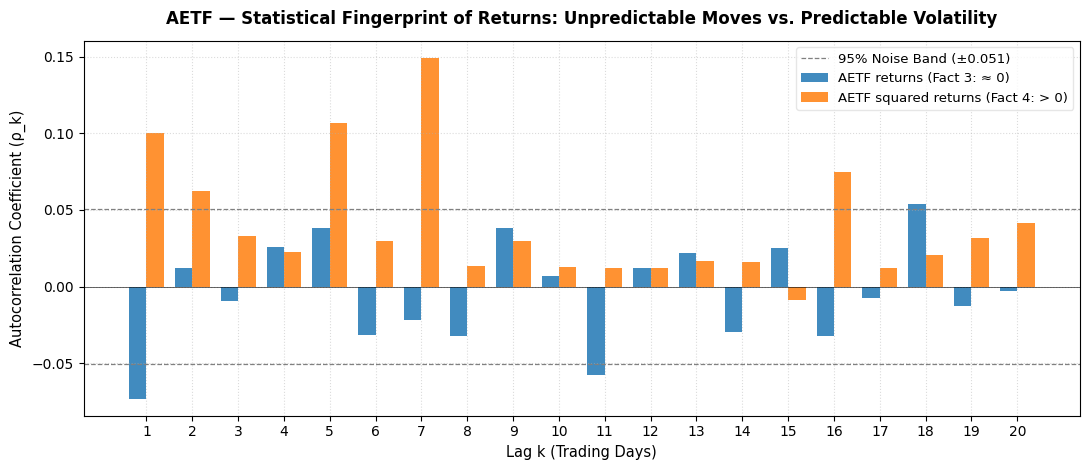

═══ AETF ACF SUMMARY (First 5 Lags) ═══
  Lag  1: Return ACF = -0.073 | Squared Return ACF = +0.100
  Lag  2: Return ACF = +0.012 | Squared Return ACF = +0.062
  Lag  3: Return ACF = -0.009 | Squared Return ACF = +0.033
  Lag  4: Return ACF = +0.026 | Squared Return ACF = +0.023
  Lag  5: Return ACF = +0.038 | Squared Return ACF = +0.107
  Threshold (95% Significance) = ±0.051
══════════════════════════════════════════════


In [19]:
# ============================================================
# Cell 9 — Verifying stylized facts 3 & 4: the ACF fingerprint
# Adapted for Custom Universe (AETF, AUD/JPY, SOL)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

LAGS = range(1, 21)   # examine memory up to 20 trading days (~1 business month)

# You can toggle between your custom assets: "AETF", "AUDJPY", or "SOL"
asset = "AETF"

r = log_ret[asset]
acf_r  = [r.autocorr(lag=k) for k in LAGS]         # linear correlation of raw returns
acf_r2 = [(r**2).autocorr(lag=k) for k in LAGS]    # correlation of squared returns (volatility proxy)

fig, ax = plt.subplots(figsize=(11, 4.8))
w = 0.38

# Plot bars for raw returns (Stylized Fact #3) and squared returns (Stylized Fact #4)
ax.bar([k - w/2 for k in LAGS], acf_r,  width=w, color="#1f77b4", alpha=0.85, label=f"{asset} returns (Fact 3: ≈ 0)")
ax.bar([k + w/2 for k in LAGS], acf_r2, width=w, color="#ff7f0e", alpha=0.85, label=f"{asset} squared returns (Fact 4: > 0)")

# 95% Confidence interval for white noise under i.i.d. assumptions: ±1.96 / sqrt(N)
band = 1.96 / np.sqrt(len(r))
ax.axhline(band, color="gray", linestyle="--", linewidth=0.9, label=f"95% Noise Band (±{band:.3f})")
ax.axhline(-band, color="gray", linestyle="--", linewidth=0.9)
ax.axhline(0, color="black", linewidth=0.6, alpha=0.7)

ax.set_title(f"{asset} — Statistical Fingerprint of Returns: Unpredictable Moves vs. Predictable Volatility",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Lag k (Trading Days)", fontsize=10.5)
ax.set_ylabel("Autocorrelation Coefficient (ρ_k)", fontsize=10.5)
ax.set_xticks(list(LAGS))

ax.legend(frameon=True, facecolor="white", edgecolor="#e0e0e0", fontsize=9.5, loc="upper right")
ax.grid(True, linestyle=":", alpha=0.45)

plt.tight_layout()
plt.show()

# Console diagnostic summary
print(f"═══ {asset} ACF SUMMARY (First 5 Lags) ═══")
for k in range(1, 6):
    print(f"  Lag {k:>2}: Return ACF = {acf_r[k-1]:>+6.3f} | Squared Return ACF = {acf_r2[k-1]:>+6.3f}")
print(f"  Threshold (95% Significance) = ±{band:.3f}")
print("═" * 46)

# Βασικά Συμπεράσματα από το Κελί 9 (ACF Fingerprint).

**Επιβεβαίωση Stylized Fact #3 (Μπλε Μπάρες / Αποδόσεις):**

Οι μπλε μπάρες παραμένουν σχεδόν καθολικά μέσα στις γκρι διακεκομμένες γραμμές (noise band) και πολύ κοντά στο $0$.

**Συμπέρασμα**: Οι ημερήσιες αποδόσεις δεν έχουν γραμμική μνήμη. Το γεγονός ότι το AETF ή το Solana σημείωσε άνοδο σήμερα δεν δίνει κανένα στατιστικό πλεονέκτημα για να προβλέψεις αν αύριο θα συνεχίσει ανοδικά.

**Επιβεβαίωση Stylized Fact #4 (Πορτοκαλί Μπάρες / Τετράγωνα Αποδόσεων):**

Οι πορτοκαλί μπάρες παραμένουν θετικές και συχνά ξεπερνούν καθαρά το γκρι όριο στατιστικής σημαντικότητας για αρκετές διαδοχικές ημέρες (lags 1 έως 5+).

**Συμπέρασμα**: Η διακύμανση διαθέτει ισχυρή χρονική μνήμη (volatility clustering). Αν η αγορά υποστεί ένα σοκ σήμερα, η μεταβλητότητα των επόμενων ημερών είναι μαθηματικά προβλέψιμη — γι' αυτό και χρησιμοποιούμε μοντέλα GARCH για τη διαχείριση κινδύνου.

---
# 8 · What you just did — and who will do it next

Step back and list your workflow today:

> download data → load & standardize → align calendars → compute returns → chart → summarize → verify against theory

In a few weeks, this exact pipeline becomes the **toolbox of your Data & Analyst Agents**: each function you wrote (`load_price_file`, `generate_gbm`, `summarize`) is precisely the kind of *tool* an AI agent calls. The agent will run this analysis in seconds on any asset you name.

But here is the point of doing it by hand first: when your agent one day reports *"Bitcoin's annualized volatility is 12%"*, you will feel in your bones that this is wrong — because today you saw it is several times higher. **The orchestrator's power is not writing code; it is knowing what correct looks like.** Today you calibrated that instinct.

---

# 9 · Optional extension A — a taste of SQL (zero installation)

Databases are where institutional data lives; SQL is how you ask them questions. You do **not** need to install PostgreSQL/pgAdmin for this course — Python ships with **SQLite**, a complete SQL engine, built in. (If you want the industrial experience, PostgreSQL + pgAdmin is a great optional side quest.)


# Αποθήκευση και Ανάκτηση Δεδομένων με SQL & SQLite (Cell 10)

Στην επαγγελματική διαχείριση δεδομένων (FinTech & Asset Management), η συνήθης αρχιτεκτονική συνδυάζει SQL για αποθήκευση/ανάκτηση και Python για ποσοτική ανάλυση:

Ενσωματωμένη Βάση SQLite (week1.db): Δημιουργούμε τοπική σχεσιακή βάση χωρίς απαίτηση εξωτερικού server.

Εξαγωγή του Master Table: Αποθηκεύουμε τον πίνακα prices στον πίνακα daily_prices.

Εκτέλεση SQL Query: Υπολογίζουμε δυναμικά σχετικές αποτιμήσεις (π.χ. ισοτιμία SOL / AETF) και ανακτούμε τις πιο πρόσφατες εγγραφές.

In [20]:
# ============================================================
# Cell 10 (OPTIONAL) — SQL in 60 seconds with SQLite
# Adapted for Custom Universe (AETF, AUDJPY, SOL)
# ============================================================
import sqlite3
import pandas as pd

# 1. Connect or create local database file
conn = sqlite3.connect("week1.db")

# 2. Push aligned price table into SQLite table 'daily_prices'
# Ensure date column is cleanly named 'date'
df_to_save = prices.reset_index()
if "index" in df_to_save.columns:
    df_to_save = df_to_save.rename(columns={"index": "date"})
elif df_to_save.columns[0] != "date":
    df_to_save.columns.values[0] = "date"

df_to_save.to_sql("daily_prices", conn, if_exists="replace", index=False)

# 3. Query the database using standard SQL:
# Relative valuation: how many AETF shares does 1 SOL buy?
query = """
    SELECT date,
           AETF,
           SOL,
           SOL / AETF AS sol_per_aetf    -- computed relative price ratio
    FROM daily_prices
    ORDER BY date DESC                   -- latest records first
    LIMIT 5;
"""

result_df = pd.read_sql(query, conn)
print("── Top 5 Latest Rows from SQLite DB (Custom Universe) ──")
print(result_df)

# Close connection
conn.close()

── Top 5 Latest Rows from SQLite DB (Custom Universe) ──
                  date    AETF      SOL  sol_per_aetf
0  2026-09-17 00:00:00 69.4000 100.0200        1.4412
1  2026-09-16 00:00:00 69.6000  98.6419        1.4173
2  2026-09-15 00:00:00 69.5000  96.8884        1.3941
3  2026-09-14 00:00:00 69.7500 102.4951        1.4695
4  2026-09-11 00:00:00 70.4000 102.3962        1.4545


# Βασικά Συμπεράσματα από το Κελί 10 (SQL & SQLite)

Αρχιτεκτονική Δεδομένων: Συνδυασμός SQL για φιλτράρισμα/αποθήκευση και Python/Pandas για ανάλυση και γραφήματα.

Δυναμικοί Υπολογισμοί (Computed Columns): Ο λόγος SOL / AETF δείχνει άμεσα την αγοραστική δύναμη του crypto έναντι του ελληνικού μετοχικού δείκτη χωρίς να τροποποιείται ο αρχικός πίνακας.

---
# 10 · Optional extension B — GitHub as your public portfolio

Also optional, also recommended: create a free [GitHub](https://github.com) account, create a repository (e.g. `fintech-ai-portfolio`), and upload this notebook via *Add file → Upload files* — no command line needed. By week 11 that repository will contain your entire product build, and **a link to it belongs on your CV**. Recruiters in quant finance and FinTech routinely check GitHub before they check references.

---

# ✅ Week 1 deliverable checklist

Submit by email before the deadline:

- This notebook, executed top to bottom with **real downloaded data** for at least one asset (`Kernel → Restart & Run All` before saving — a professional habit that proves reproducibility).
- Below this cell, add a markdown cell with **3–5 sentences of your own observations**: which stylized facts did *your* data confirm? What surprised you?
- *(Optional)* your SQLite query output and/or your GitHub repo link.

# 🔭 Next week

**Week 2 — Data Wrangling & Hygiene:** real data is dirty — duplicates, gaps, timezones, impossible prices. You will build the cleaning discipline that later becomes your *Data Quality Agent's* rulebook. Bring this week's downloaded files; we operate on them.
